In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

#data

In [1]:
# ============================================================
# PARTIE 1 — SETUP KAGGLE (GPU P100)
# Le dataset est déjà disponible dans /kaggle/input/
# ============================================================
import os, sys, glob, random, time, warnings
import numpy as np
warnings.filterwarnings('ignore')

# ── Vérification GPU P100 ─────────────────────────────────
import torch
print(f"PyTorch     : {torch.__version__}")
print(f"CUDA dispo  : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU         : {torch.cuda.get_device_name(0)}")
    print(f"VRAM totale : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')


PyTorch     : 2.10.0+cu128
CUDA dispo  : True
GPU         : Tesla T4
VRAM totale : 15.6 GB


In [3]:
# ── Localiser le dataset (déjà monté sur Kaggle) ──────────
DATASET_ROOT = '/kaggle/input/datasets/sayedgamal99/smoke-fire-detection-yolo'
print(f"\nDataset path : {DATASET_ROOT}")
print(f"Existe       : {os.path.exists(DATASET_ROOT)}")

# Explorer la structure
print("\nStructure du dataset :")
for root, dirs, files_list in os.walk(DATASET_ROOT):
    level = root.replace(DATASET_ROOT, '').count(os.sep)
    if level < 3:
        indent = '  ' * level
        print(f"{indent}{os.path.basename(root)}/")
        if level == 2:
            imgs = [f for f in files_list if f.endswith(('.jpg','.png','.jpeg'))]
            txts = [f for f in files_list if f.endswith('.txt')]
            if imgs: print(f"{indent}  → {len(imgs)} images")
            if txts: print(f"{indent}  → {len(txts)} labels")
print("exict")


Dataset path : /kaggle/input/datasets/sayedgamal99/smoke-fire-detection-yolo
Existe       : True

Structure du dataset :
smoke-fire-detection-yolo/
  data/
    val/
    test/
    train/
exict


In [4]:
# ── Dossier de sortie Kaggle ──────────────────────────────
OUTPUT_DIR = '/kaggle/working/models'
os.makedirs(OUTPUT_DIR, exist_ok=True)
print(f"\nOutput dir : {OUTPUT_DIR} ✓")



Output dir : /kaggle/working/models ✓


In [5]:
# ── Installer dépendances manquantes ──────────────────────
# Kaggle a déjà torch, torchvision, PIL, matplotlib
# pickle est dans la stdlib
print("\nDépendances OK (environnement Kaggle natif)")

# ── Config globale ────────────────────────────────────────
CONFIG = {
    'num_classes'  : 3,        # 0=background, 1=fire, 2=smoke
    'img_size'     : 224,
    'batch_size'   : 64,       # P100 = 16 GB VRAM → batch plus grand
    'num_epochs'   : 40,
    'lr'           : 3e-4,
    'temperature'  : 4.0,
    'lambda_kd'    : 0.7,
    'save_every'   : 5,
    'num_workers'  : 4,        # P100 Kaggle supporte 4 workers
    'seed'         : 42,
}

print("exict")


Dépendances OK (environnement Kaggle natif)
exict


In [6]:
# Fixer les seeds pour reproductibilité
random.seed(CONFIG['seed'])
np.random.seed(CONFIG['seed'])
torch.manual_seed(CONFIG['seed'])
torch.cuda.manual_seed_all(CONFIG['seed'])
torch.backends.cudnn.benchmark     = True   # accélère les convolutions
torch.backends.cudnn.deterministic = False  # désactivé pour perf max

print(f"\nConfig chargée : {CONFIG}")
print("\n✓ Partie 1 terminée")


Config chargée : {'num_classes': 3, 'img_size': 224, 'batch_size': 64, 'num_epochs': 40, 'lr': 0.0003, 'temperature': 4.0, 'lambda_kd': 0.7, 'save_every': 5, 'num_workers': 4, 'seed': 42}

✓ Partie 1 terminée


In [7]:
# ============================================================
# PARTIE 2 — DATASET & DATALOADER
# Lit directement depuis /kaggle/input/smoke-fire-detection-yolo
# ============================================================
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import os, glob, random

# ── Parser labels YOLO ────────────────────────────────────
def parse_yolo_label(label_path, num_classes=3):
    if not os.path.exists(label_path):
        return 0
    with open(label_path, 'r') as f:
        lines = f.read().strip().split('\n')
    if not lines or lines[0] == '':
        return 0
    classes = []
    for line in lines:
        parts = line.strip().split()
        if parts:
            cls = int(parts[0])
            classes.append(min(cls, num_classes - 1))
    if not classes:
        return 0
    return max(set(classes), key=classes.count)


# ── Dataset YOLO ──────────────────────────────────────────
class YOLOFireDataset(Dataset):
    def __init__(self, root_dir, split='train', transform=None,
                 num_classes=3, max_samples=None):
        self.transform    = transform
        self.num_classes  = num_classes
        self.image_paths  = []
        self.label_paths  = []

        # Structures possibles dans le dataset Kaggle
        candidates = [
            os.path.join(root_dir, split, 'images'),
            os.path.join(root_dir, 'images', split),
            os.path.join(root_dir, split),
        ]

        img_dir = None
        for c in candidates:
            if os.path.isdir(c):
                imgs = (glob.glob(os.path.join(c, '*.jpg'))
                      + glob.glob(os.path.join(c, '*.png'))
                      + glob.glob(os.path.join(c, '*.jpeg')))
                if imgs:
                    img_dir = c
                    self.image_paths = sorted(imgs)
                    break

        # Fallback : tout parcourir et splitter manuellement
        if not self.image_paths:
            all_imgs = []
            for ext in ['*.jpg', '*.png', '*.jpeg']:
                all_imgs += glob.glob(
                    os.path.join(root_dir, '**', ext), recursive=True)
            all_imgs = sorted(set(all_imgs))
            random.seed(42)
            random.shuffle(all_imgs)
            n = len(all_imgs)
            splits = {
                'train': all_imgs[:int(0.70 * n)],
                'valid': all_imgs[int(0.70 * n):int(0.85 * n)],
                'test' : all_imgs[int(0.85 * n):]
            }
            self.image_paths = splits.get(split, splits['train'])

        # Construire les chemins de labels
        for img_path in self.image_paths:
            lbl = (img_path
                   .replace('/images/', '/labels/')
                   .replace('\\images\\', '\\labels\\'))
            lbl = os.path.splitext(lbl)[0] + '.txt'
            self.label_paths.append(lbl)

        if max_samples and len(self.image_paths) > max_samples:
            idx = random.sample(range(len(self.image_paths)), max_samples)
            self.image_paths = [self.image_paths[i] for i in idx]
            self.label_paths = [self.label_paths[i] for i in idx]

        print(f"  [{split:>5}] {len(self.image_paths):>5} images  "
              f"| labels trouvés : "
              f"{sum(os.path.exists(l) for l in self.label_paths)}")

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        try:
            img = Image.open(self.image_paths[idx]).convert('RGB')
        except Exception:
            img = Image.new('RGB', (224, 224))
        label = parse_yolo_label(self.label_paths[idx], self.num_classes)
        if self.transform:
            img = self.transform(img)
        return img, torch.tensor(label, dtype=torch.long)


# ── Transforms ────────────────────────────────────────────
IMG_SIZE = CONFIG['img_size']

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE + 32, IMG_SIZE + 32)),
    transforms.RandomCrop(IMG_SIZE),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(p=0.2),
    transforms.ColorJitter(brightness=0.35, contrast=0.35, saturation=0.25),
    transforms.RandomRotation(20),
    transforms.RandomGrayscale(p=0.05),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# ── Créer les datasets ────────────────────────────────────
print("Chargement des datasets depuis :", DATASET_ROOT)
train_dataset = YOLOFireDataset(DATASET_ROOT, split='train',
                                transform=train_transform,
                                num_classes=CONFIG['num_classes'])
val_dataset   = YOLOFireDataset(DATASET_ROOT, split='valid',
                                transform=val_transform,
                                num_classes=CONFIG['num_classes'])
test_dataset  = YOLOFireDataset(DATASET_ROOT, split='test',
                                transform=val_transform,
                                num_classes=CONFIG['num_classes'])

# ── DataLoaders ───────────────────────────────────────────
BS = CONFIG['batch_size']
NW = CONFIG['num_workers']

train_loader = DataLoader(train_dataset, batch_size=BS, shuffle=True,
                          num_workers=NW, pin_memory=True,
                          drop_last=True, persistent_workers=True)
val_loader   = DataLoader(val_dataset,   batch_size=BS * 2, shuffle=False,
                          num_workers=NW, pin_memory=True,
                          persistent_workers=True)
test_loader  = DataLoader(test_dataset,  batch_size=BS * 2, shuffle=False,
                          num_workers=NW, pin_memory=True,
                          persistent_workers=True)

print(f"\nTrain  : {len(train_dataset)} images → {len(train_loader)} batchs")
print(f"Val    : {len(val_dataset)}  images → {len(val_loader)} batchs")
print(f"Test   : {len(test_dataset)}  images → {len(test_loader)} batchs")

# Test un batch
imgs, labels = next(iter(train_loader))
print(f"\nBatch shape  : {imgs.shape}")
print(f"Labels uniq  : {labels.unique().tolist()}")
print(f"GPU mémoire  : {torch.cuda.memory_allocated()/1e6:.0f} MB")
print("\n✓ Partie 2 terminée")

Chargement des datasets depuis : /kaggle/input/datasets/sayedgamal99/smoke-fire-detection-yolo
  [train] 15068 images  | labels trouvés : 15068
  [valid]  3229 images  | labels trouvés : 3229
  [ test]  3230 images  | labels trouvés : 3230

Train  : 15068 images → 235 batchs
Val    : 3229  images → 26 batchs
Test   : 3230  images → 26 batchs

Batch shape  : torch.Size([64, 3, 224, 224])
Labels uniq  : [0, 1]
GPU mémoire  : 0 MB

✓ Partie 2 terminée


#Model A

In [8]:
# ============================================================
# PARTIE 3 — MODEL A : MobileNetV2
# ============================================================
import torch
import torch.nn as nn
import torchvision.models as models
import pickle

# ── Architecture ──────────────────────────────────────────
class ModelA(nn.Module):
    def __init__(self, num_classes=3):
        super(ModelA, self).__init__()
        backbone = models.mobilenet_v2(
            weights=models.MobileNet_V2_Weights.IMAGENET1K_V1)
        self.features = backbone.features
        self.pool     = nn.AdaptiveAvgPool2d((1, 1))
        self.classifier = nn.Sequential(
            nn.Dropout(0.3),
            nn.Linear(1280, 512),
            nn.ReLU(inplace=True),
            nn.BatchNorm1d(512),
            nn.Dropout(0.2),
            nn.Linear(512, 256),
            nn.ReLU(inplace=True),
            nn.Linear(256, num_classes)
        )
        self.projector = nn.Sequential(
            nn.Linear(1280, 256),
            nn.ReLU(),
            nn.Linear(256, 128)
        )

    def forward(self, x, return_features=False):
        feat   = self.features(x)
        pooled = self.pool(feat).flatten(1)
        logits = self.classifier(pooled)
        if return_features:
            return logits, self.projector(pooled)
        return logits

    def get_soft_labels(self, x, temperature=4.0):
        logits, proj = self.forward(x, return_features=True)
        soft = torch.softmax(logits / temperature, dim=-1)
        return logits, soft, proj


print("exect")

exect


In [9]:
# ── Instanciation ─────────────────────────────────────────
model_a = ModelA(num_classes=CONFIG['num_classes']).to(DEVICE)

dummy = torch.randn(2, 3, 224, 224).to(DEVICE)
with torch.no_grad():
    out, soft, proj = model_a.get_soft_labels(dummy)

n_params = sum(p.numel() for p in model_a.parameters())
print(f"ModelA  | params : {n_params:,}")
print(f"Output  : {out.shape}  Soft : {soft.shape}  Proj : {proj.shape}")

# ── Sauvegarde initiale ────────────────────────────────────
ckpt_a_init = {
    'model_state_dict': model_a.state_dict(),
    'model_class'     : 'ModelA',
    'architecture'    : 'MobileNetV2',
    'num_classes'     : CONFIG['num_classes'],
    'version'         : 'initial'
}
with open(f"{OUTPUT_DIR}/modelA.pkl", 'wb') as f:
    pickle.dump(ckpt_a_init, f)

print(f"\n✓ modelA.pkl sauvegardé → {OUTPUT_DIR}/modelA.pkl")
print("✓ Partie 3 terminée")

Downloading: "https://download.pytorch.org/models/mobilenet_v2-b0353104.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-b0353104.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 155MB/s]


ModelA  | params : 3,373,699
Output  : torch.Size([2, 3])  Soft : torch.Size([2, 3])  Proj : torch.Size([2, 128])

✓ modelA.pkl sauvegardé → /kaggle/working/models/modelA.pkl
✓ Partie 3 terminée


Model B

In [10]:
# ============================================================
# PARTIE 4 — MODEL B : EfficientNet-B0
# ============================================================
import torch
import torch.nn as nn
import torchvision.models as models
import pickle

# ── Architecture ──────────────────────────────────────────
class ModelB(nn.Module):
    def __init__(self, num_classes=3):
        super(ModelB, self).__init__()
        backbone = models.efficientnet_b0(
            weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1)
        self.features = backbone.features
        self.avgpool  = backbone.avgpool
        self.classifier = nn.Sequential(
            nn.Dropout(0.4),
            nn.Linear(1280, 640),
            nn.SiLU(inplace=True),
            nn.BatchNorm1d(640),
            nn.Dropout(0.2),
            nn.Linear(640, 320),
            nn.SiLU(inplace=True),
            nn.Linear(320, num_classes)
        )
        self.projector = nn.Sequential(
            nn.Linear(1280, 256),
            nn.SiLU(),
            nn.Linear(256, 128)
        )

    def forward(self, x, return_features=False):
        feat   = self.features(x)
        pooled = self.avgpool(feat).flatten(1)
        logits = self.classifier(pooled)
        if return_features:
            return logits, self.projector(pooled)
        return logits

    def get_soft_labels(self, x, temperature=4.0):
        logits, proj = self.forward(x, return_features=True)
        soft = torch.softmax(logits / temperature, dim=-1)
        return logits, soft, proj


# ── Instanciation ─────────────────────────────────────────
model_b = ModelB(num_classes=CONFIG['num_classes']).to(DEVICE)

with torch.no_grad():
    out_b, soft_b, proj_b = model_b.get_soft_labels(dummy)

n_params_b = sum(p.numel() for p in model_b.parameters())
print(f"ModelB  | params : {n_params_b:,}")
print(f"Output  : {out_b.shape}  Soft : {soft_b.shape}  Proj : {proj_b.shape}")

# ── Sauvegarde initiale ────────────────────────────────────
ckpt_b_init = {
    'model_state_dict': model_b.state_dict(),
    'model_class'     : 'ModelB',
    'architecture'    : 'EfficientNet-B0',
    'num_classes'     : CONFIG['num_classes'],
    'version'         : 'initial'
}
with open(f"{OUTPUT_DIR}/modelB.pkl", 'wb') as f:
    pickle.dump(ckpt_b_init, f)

print(f"\n✓ modelB.pkl sauvegardé → {OUTPUT_DIR}/modelB.pkl")

# ── Récap des deux modèles ─────────────────────────────────
print("\n=== Modèles prêts ===")
for name, path in [('modelA.pkl', f"{OUTPUT_DIR}/modelA.pkl"),
                   ('modelB.pkl', f"{OUTPUT_DIR}/modelB.pkl")]:
    size = os.path.getsize(path) / 1e6
    print(f"  {name} : {size:.1f} MB")

print("\n✓ Partie 4 terminée")

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 170MB/s]


ModelB  | params : 5,395,583
Output  : torch.Size([2, 3])  Soft : torch.Size([2, 3])  Proj : torch.Size([2, 128])

✓ modelB.pkl sauvegardé → /kaggle/working/models/modelB.pkl

=== Modèles prêts ===
  modelA.pkl : 13.7 MB
  modelB.pkl : 21.9 MB

✓ Partie 4 terminée


Entrainment Online KD/DML

In [11]:
# ============================================================
# PARTIE 5 — ONLINE KD : DEEP MUTUAL LEARNING
# P100 = 16 GB → batch 64, mixed precision, deux modèles en //
# ============================================================
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.cuda.amp import GradScaler, autocast
import pickle, time, os
import numpy as np
from copy import deepcopy

# ── Loss DML ──────────────────────────────────────────────
class DMLLoss(nn.Module):
    def __init__(self, temperature=4.0, lambda_kd=0.7):
        super().__init__()
        self.T         = temperature
        self.lambda_kd = lambda_kd
        self.ce        = nn.CrossEntropyLoss(label_smoothing=0.1)

    def kl_div(self, p_logits, q_logits):
        p_log = F.log_softmax(p_logits / self.T, dim=-1)
        q_sft = F.softmax(q_logits  / self.T, dim=-1)
        return F.kl_div(p_log, q_sft, reduction='batchmean') * (self.T ** 2)

    def forward(self, logits_a, logits_b, labels):
        loss_task_a = self.ce(logits_a, labels)
        loss_task_b = self.ce(logits_b, labels)
        loss_kd_a   = self.kl_div(logits_a, logits_b.detach())
        loss_kd_b   = self.kl_div(logits_b, logits_a.detach())
        lam = self.lambda_kd
        loss_a = (1 - lam) * loss_task_a + lam * loss_kd_a
        loss_b = (1 - lam) * loss_task_b + lam * loss_kd_b
        return loss_a, loss_b, {
            'task_a': loss_task_a.item(), 'task_b': loss_task_b.item(),
            'kd_a'  : loss_kd_a.item(),   'kd_b'  : loss_kd_b.item()
        }


# ── Evaluation ────────────────────────────────────────────
@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    correct, total, total_loss = 0, 0, 0.0
    ce = nn.CrossEntropyLoss()
    for imgs, labels in loader:
        imgs, labels = (imgs.to(DEVICE, non_blocking=True),
                        labels.to(DEVICE, non_blocking=True))
        with autocast():
            logits = model(imgs)
        total_loss += ce(logits, labels).item()
        correct    += (logits.argmax(1) == labels).sum().item()
        total      += labels.size(0)
    model.train()
    return correct / total * 100, total_loss / len(loader)


# ── Setup entraînement ────────────────────────────────────
criterion   = DMLLoss(CONFIG['temperature'], CONFIG['lambda_kd'])
optimizer_a = optim.AdamW(model_a.parameters(), lr=CONFIG['lr'], weight_decay=1e-4)
optimizer_b = optim.AdamW(model_b.parameters(), lr=CONFIG['lr'], weight_decay=1e-4)
scheduler_a = optim.lr_scheduler.CosineAnnealingWarmRestarts(
                  optimizer_a, T_0=10, T_mult=1, eta_min=1e-6)
scheduler_b = optim.lr_scheduler.CosineAnnealingWarmRestarts(
                  optimizer_b, T_0=10, T_mult=1, eta_min=1e-6)
scaler_a    = GradScaler()
scaler_b    = GradScaler()

history = {k: [] for k in [
    'train_loss_a','train_loss_b',
    'val_acc_a','val_acc_b',
    'val_loss_a','val_loss_b',
    'kd_a','kd_b','task_a','task_b']}

best_acc_a, best_acc_b   = 0.0, 0.0
best_state_a, best_state_b = None, None

NUM_EPOCHS = CONFIG['num_epochs']
SAVE_EVERY = CONFIG['save_every']

print(f"Démarrage DML — {NUM_EPOCHS} epochs")
print(f"T={CONFIG['temperature']} | λ={CONFIG['lambda_kd']} | "
      f"BS={CONFIG['batch_size']} | LR={CONFIG['lr']}")
print("=" * 70)

for epoch in range(1, NUM_EPOCHS + 1):
    model_a.train(); model_b.train()
    ep = {k: [] for k in ['a','b','kd_a','kd_b','task_a','task_b']}
    t0 = time.time()

    for batch_idx, (imgs, labels) in enumerate(train_loader):
        imgs   = imgs.to(DEVICE,   non_blocking=True)
        labels = labels.to(DEVICE, non_blocking=True)

        with autocast():
            logits_a = model_a(imgs)
            logits_b = model_b(imgs)
            loss_a, loss_b, details = criterion(logits_a, logits_b, labels)

        # Backward A
        optimizer_a.zero_grad(set_to_none=True)
        scaler_a.scale(loss_a).backward(retain_graph=True)
        scaler_a.unscale_(optimizer_a)
        nn.utils.clip_grad_norm_(model_a.parameters(), 1.0)
        scaler_a.step(optimizer_a); scaler_a.update()

        # Backward B
        optimizer_b.zero_grad(set_to_none=True)
        scaler_b.scale(loss_b).backward()
        scaler_b.unscale_(optimizer_b)
        nn.utils.clip_grad_norm_(model_b.parameters(), 1.0)
        scaler_b.step(optimizer_b); scaler_b.update()

        ep['a'].append(loss_a.item())
        ep['b'].append(loss_b.item())
        ep['kd_a'].append(details['kd_a'])
        ep['kd_b'].append(details['kd_b'])
        ep['task_a'].append(details['task_a'])
        ep['task_b'].append(details['task_b'])

        del logits_a, logits_b, loss_a, loss_b

    scheduler_a.step(); scheduler_b.step()

    val_acc_a, val_loss_a = evaluate(model_a, val_loader)
    val_acc_b, val_loss_b = evaluate(model_b, val_loader)

    avg = lambda lst: sum(lst) / len(lst)
    history['train_loss_a'].append(avg(ep['a']))
    history['train_loss_b'].append(avg(ep['b']))
    history['val_acc_a'].append(val_acc_a)
    history['val_acc_b'].append(val_acc_b)
    history['val_loss_a'].append(val_loss_a)
    history['val_loss_b'].append(val_loss_b)
    history['kd_a'].append(avg(ep['kd_a']))
    history['kd_b'].append(avg(ep['kd_b']))
    history['task_a'].append(avg(ep['task_a']))
    history['task_b'].append(avg(ep['task_b']))

    if val_acc_a > best_acc_a:
        best_acc_a   = val_acc_a
        best_state_a = deepcopy(model_a.state_dict())
    if val_acc_b > best_acc_b:
        best_acc_b   = val_acc_b
        best_state_b = deepcopy(model_b.state_dict())

    print(f"Ep {epoch:2d}/{NUM_EPOCHS} | "
          f"Loss A={avg(ep['a']):.4f} B={avg(ep['b']):.4f} | "
          f"ValAcc A={val_acc_a:.1f}% B={val_acc_b:.1f}% | "
          f"KD A={avg(ep['kd_a']):.4f} B={avg(ep['kd_b']):.4f} | "
          f"{time.time()-t0:.0f}s")

    if epoch % SAVE_EVERY == 0:
        for tag, state, acc in [
            ('A', model_a.state_dict(), val_acc_a),
            ('B', model_b.state_dict(), val_acc_b)
        ]:
            path = f"{OUTPUT_DIR}/model{tag}_ep{epoch}.pkl"
            with open(path, 'wb') as f:
                pickle.dump({'model_state_dict': state,
                             'epoch': epoch, 'val_acc': acc,
                             'history': history}, f)
        print(f"  ✓ Checkpoints epoch {epoch} sauvegardés")

# ── Sauvegarder les meilleurs modèles finaux ──────────────
for tag, state, acc, arch in [
    ('A', best_state_a, best_acc_a, 'MobileNetV2-DML'),
    ('B', best_state_b, best_acc_b, 'EfficientNet-B0-DML')
]:
    path = f"{OUTPUT_DIR}/model{tag}.pkl"
    with open(path, 'wb') as f:
        pickle.dump({
            'model_state_dict': state,
            'architecture'    : arch,
            'best_val_acc'    : acc,
            'training'        : 'OnlineKD-DML',
            'temperature'     : CONFIG['temperature'],
            'lambda_kd'       : CONFIG['lambda_kd'],
            'history'         : history,
            'num_classes'     : CONFIG['num_classes']
        }, f)
    print(f"✓ model{tag}.pkl → best val acc = {acc:.2f}%")

print("\n✓ Partie 5 terminée")

Démarrage DML — 40 epochs
T=4.0 | λ=0.7 | BS=64 | LR=0.0003
Ep  1/40 | Loss A=0.1721 B=0.1734 | ValAcc A=91.8% B=91.8% | KD A=0.0337 B=0.0337 | 208s
Ep  2/40 | Loss A=0.1457 B=0.1447 | ValAcc A=93.1% B=93.6% | KD A=0.0233 B=0.0233 | 112s
Ep  3/40 | Loss A=0.1413 B=0.1401 | ValAcc A=93.2% B=92.4% | KD A=0.0216 B=0.0216 | 113s
Ep  4/40 | Loss A=0.1369 B=0.1350 | ValAcc A=93.2% B=93.3% | KD A=0.0193 B=0.0193 | 112s
Ep  5/40 | Loss A=0.1340 B=0.1318 | ValAcc A=92.8% B=93.7% | KD A=0.0174 B=0.0174 | 112s
  ✓ Checkpoints epoch 5 sauvegardés
Ep  6/40 | Loss A=0.1301 B=0.1279 | ValAcc A=93.7% B=94.2% | KD A=0.0161 B=0.0161 | 112s
Ep  7/40 | Loss A=0.1270 B=0.1249 | ValAcc A=94.0% B=94.4% | KD A=0.0146 B=0.0146 | 112s
Ep  8/40 | Loss A=0.1244 B=0.1226 | ValAcc A=94.2% B=94.5% | KD A=0.0134 B=0.0134 | 113s
Ep  9/40 | Loss A=0.1222 B=0.1202 | ValAcc A=94.2% B=94.7% | KD A=0.0130 B=0.0130 | 113s
Ep 10/40 | Loss A=0.1208 B=0.1195 | ValAcc A=94.5% B=94.7% | KD A=0.0121 B=0.0121 | 113s
  ✓ Checkpoint

teste des image

Chargement des modèles entraînés...
  ✓ modelA.pkl | val acc = 94.85908950139363
  ✓ modelB.pkl | val acc = 95.04490554351193
Test sur 4 images du dataset


──────────────────────────────────────────────────
Image : AoF04660.jpg
Taille : 1280×720

══════════════════════════════════════════════════════════
        RAPPORT DE DÉTECTION  —  OnlineKD DML
══════════════════════════════════════════════════════════

  MODEL A  MobileNetV2
  ────────────────────────────────────────────
  🟢 Background   ██████████                   36.1%
  🔥 Fire         ████████████████             59.6% ◄
  💨 Smoke        █                            4.3%

  Zones détectées : 2
    → Fire       conf=77.5%  bbox=(80,160)→(240,320)
    → Fire       conf=73.6%  bbox=(0,224)→(224,448)

  MODEL B  EfficientNet-B0
  ────────────────────────────────────────────
  🟢 Background   █████████                    33.2%
  🔥 Fire         █████████████████            62.8% ◄
  💨 Smoke        █                            4.0%


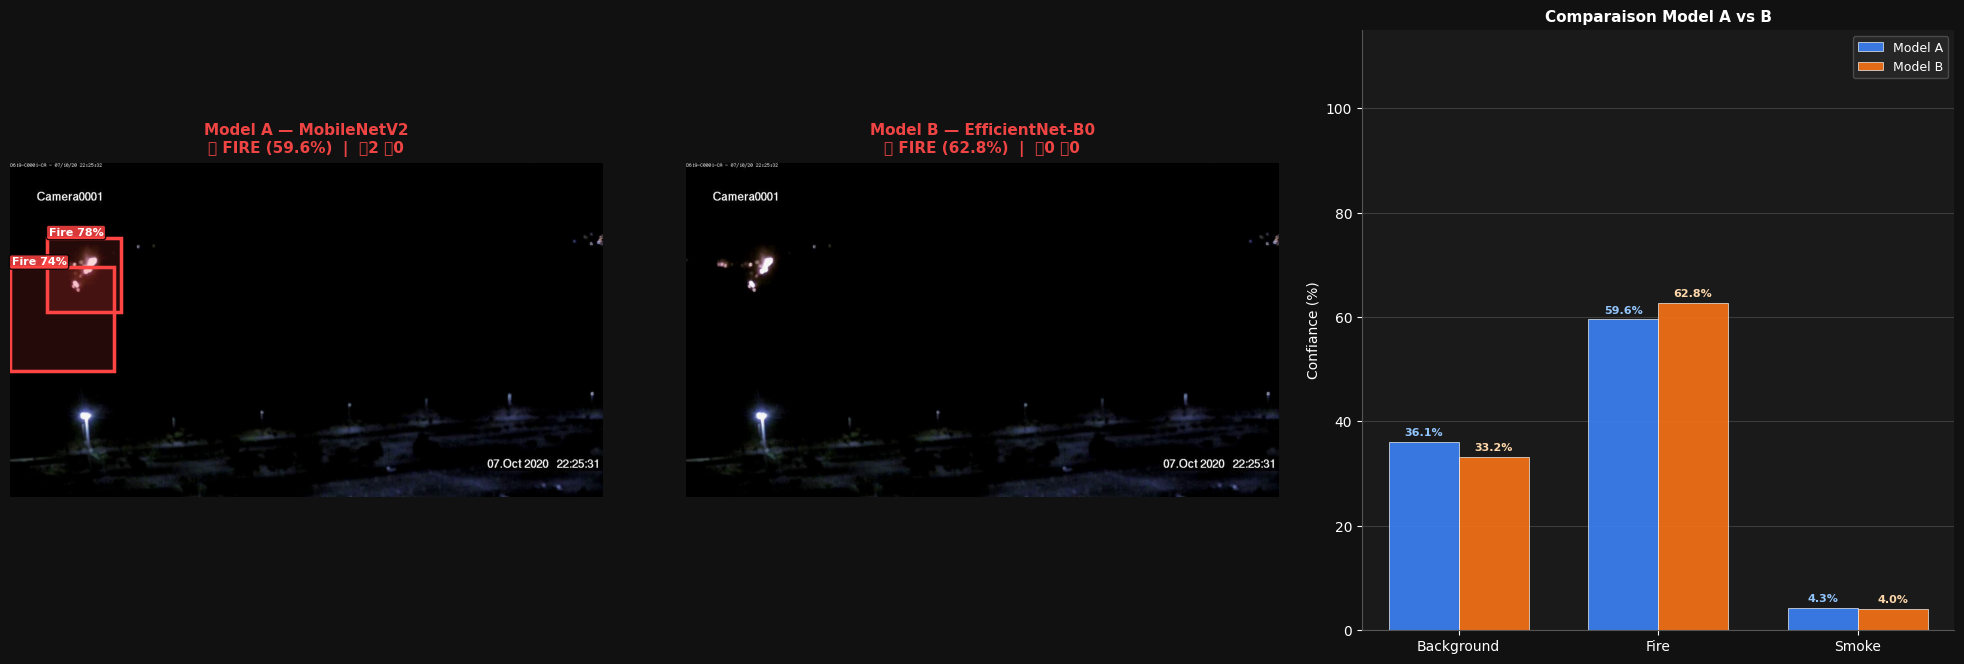

✓ Résultat sauvegardé : /kaggle/working/models/result_AoF04660.png

──────────────────────────────────────────────────
Image : WEB05194.jpg
Taille : 640×360

══════════════════════════════════════════════════════════
        RAPPORT DE DÉTECTION  —  OnlineKD DML
══════════════════════════════════════════════════════════

  MODEL A  MobileNetV2
  ────────────────────────────────────────────
  🟢 Background   █                            6.1%
  🔥 Fire         █████████████████████████    90.6% ◄
  💨 Smoke                                     3.3%

  Zones détectées : 4
    → Fire       conf=90.0%  bbox=(224,112)→(448,336)
    → Fire       conf=89.6%  bbox=(0,112)→(224,336)
    → Fire       conf=89.4%  bbox=(112,112)→(336,336)
    → Fire       conf=87.1%  bbox=(336,112)→(560,336)

  MODEL B  EfficientNet-B0
  ────────────────────────────────────────────
  🟢 Background   █                            6.5%
  🔥 Fire         █████████████████████████    90.2% ◄
  💨 Smoke                         

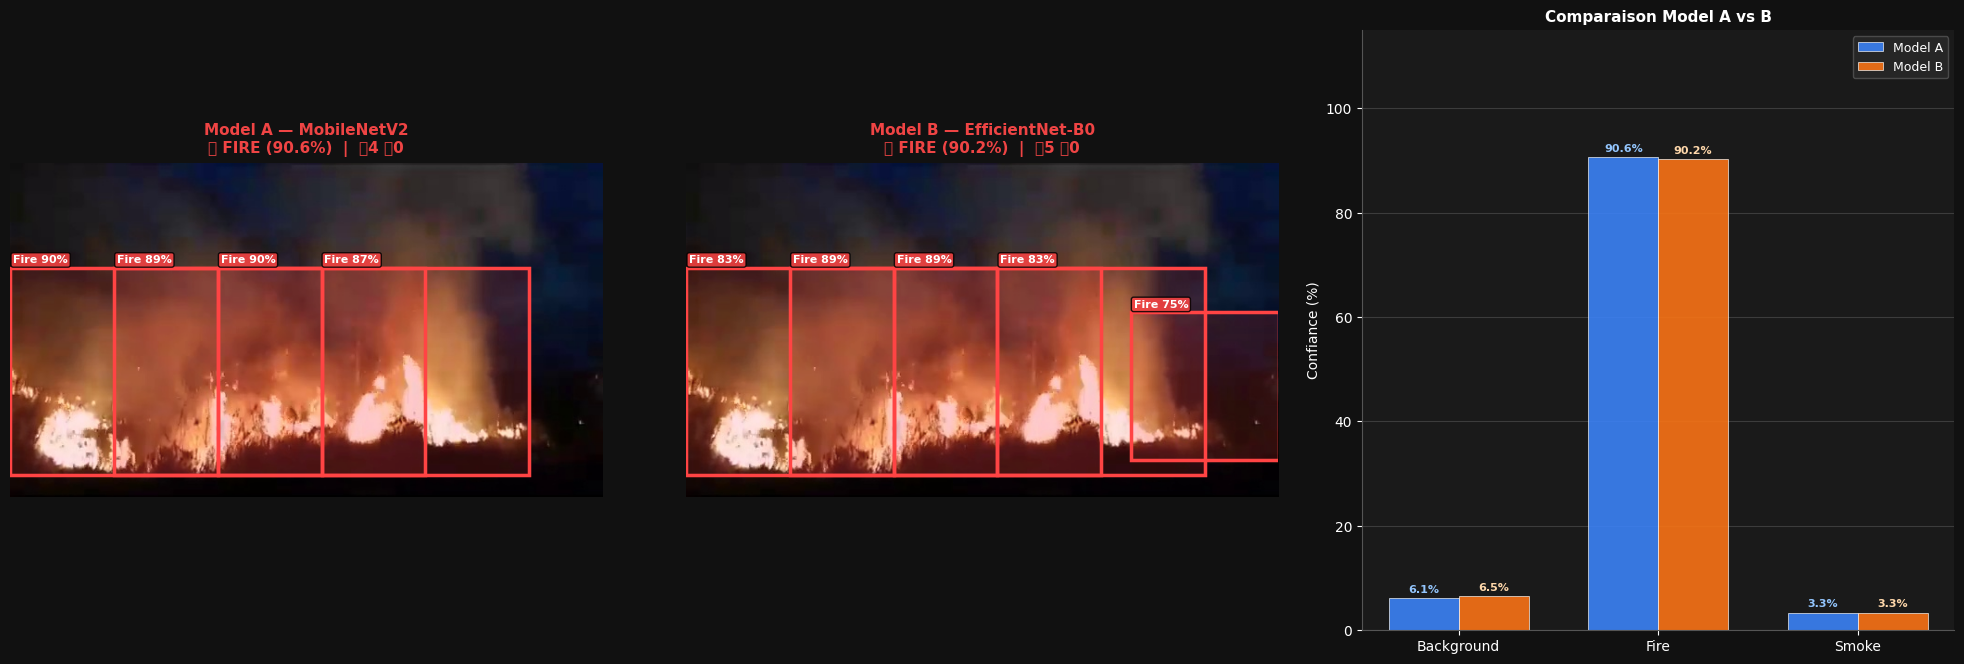

✓ Résultat sauvegardé : /kaggle/working/models/result_WEB05194.png

──────────────────────────────────────────────────
Image : AoF04762.jpg
Taille : 1280×720

══════════════════════════════════════════════════════════
        RAPPORT DE DÉTECTION  —  OnlineKD DML
══════════════════════════════════════════════════════════

  MODEL A  MobileNetV2
  ────────────────────────────────────────────
  🟢 Background   ████                         17.4%
  🔥 Fire         ██████████████████████       78.9% ◄
  💨 Smoke        █                            3.7%

  Zones détectées : 3
    → Fire       conf=70.6%  bbox=(0,160)→(160,320)
    → Fire       conf=70.5%  bbox=(112,112)→(336,336)
    → Fire       conf=70.0%  bbox=(0,224)→(224,448)

  MODEL B  EfficientNet-B0
  ────────────────────────────────────────────
  🟢 Background   ███                          13.5%
  🔥 Fire         ███████████████████████      83.0% ◄
  💨 Smoke                                     3.6%

  Zones détectées : 0

  Accord des

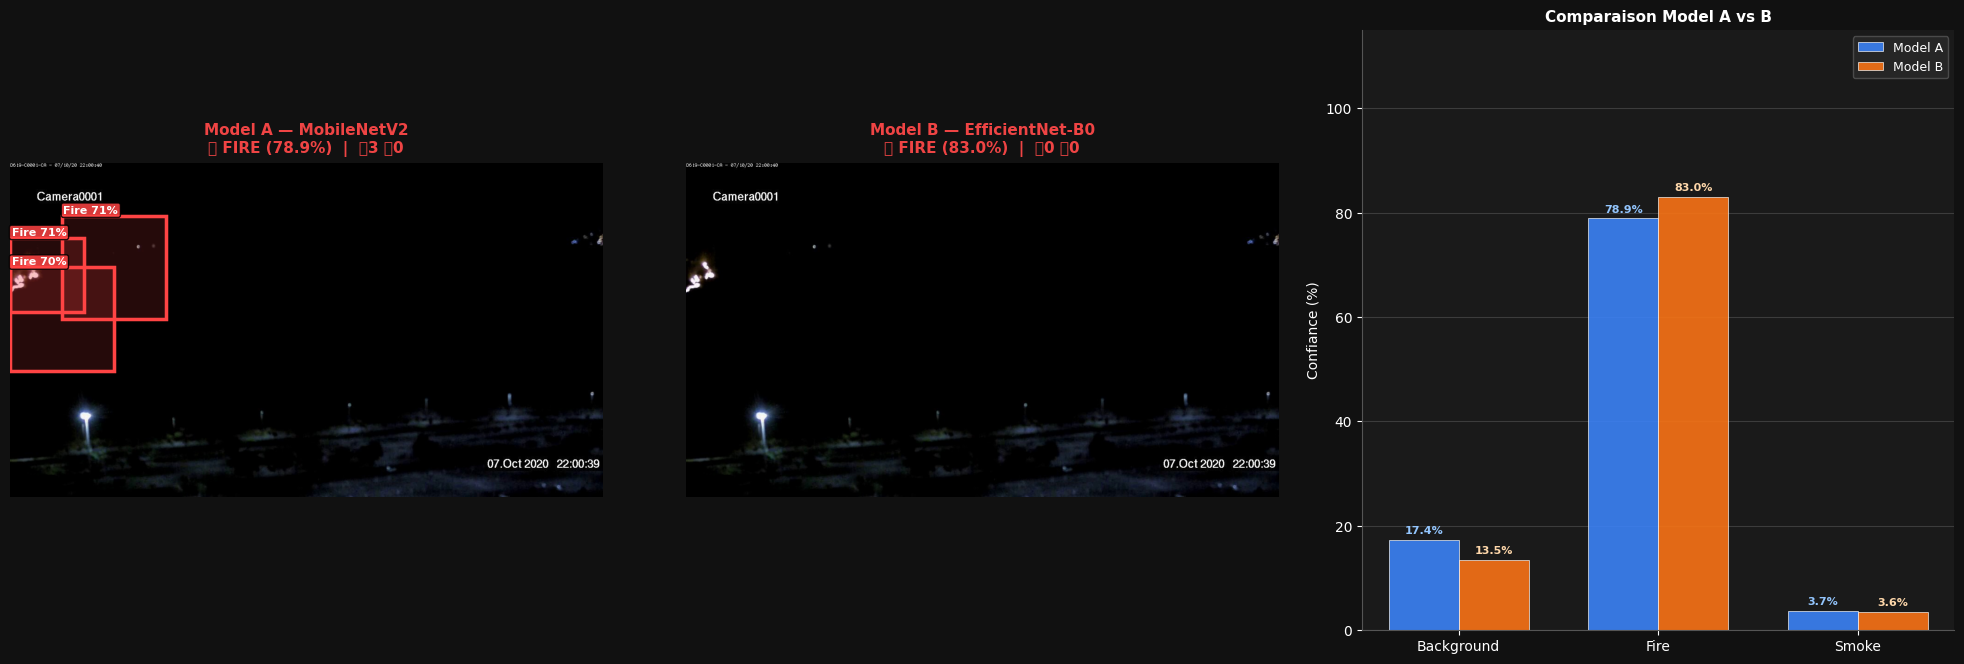

✓ Résultat sauvegardé : /kaggle/working/models/result_AoF04762.png

──────────────────────────────────────────────────
Image : WEB05365.jpg
Taille : 640×360

══════════════════════════════════════════════════════════
        RAPPORT DE DÉTECTION  —  OnlineKD DML
══════════════════════════════════════════════════════════

  MODEL A  MobileNetV2
  ────────────────────────────────────────────
  🟢 Background   ███                          14.0%
  🔥 Fire         ██████████████████████       82.1% ◄
  💨 Smoke        █                            3.9%

  Zones détectées : 5
    → Fire       conf=79.6%  bbox=(112,0)→(336,224)
    → Fire       conf=79.3%  bbox=(0,112)→(224,336)
    → Fire       conf=78.9%  bbox=(0,0)→(224,224)
    → Fire       conf=78.7%  bbox=(112,112)→(336,336)
    → Fire       conf=71.8%  bbox=(400,160)→(560,320)

  MODEL B  EfficientNet-B0
  ────────────────────────────────────────────
  🟢 Background   ███                          13.3%
  🔥 Fire         █████████████████████

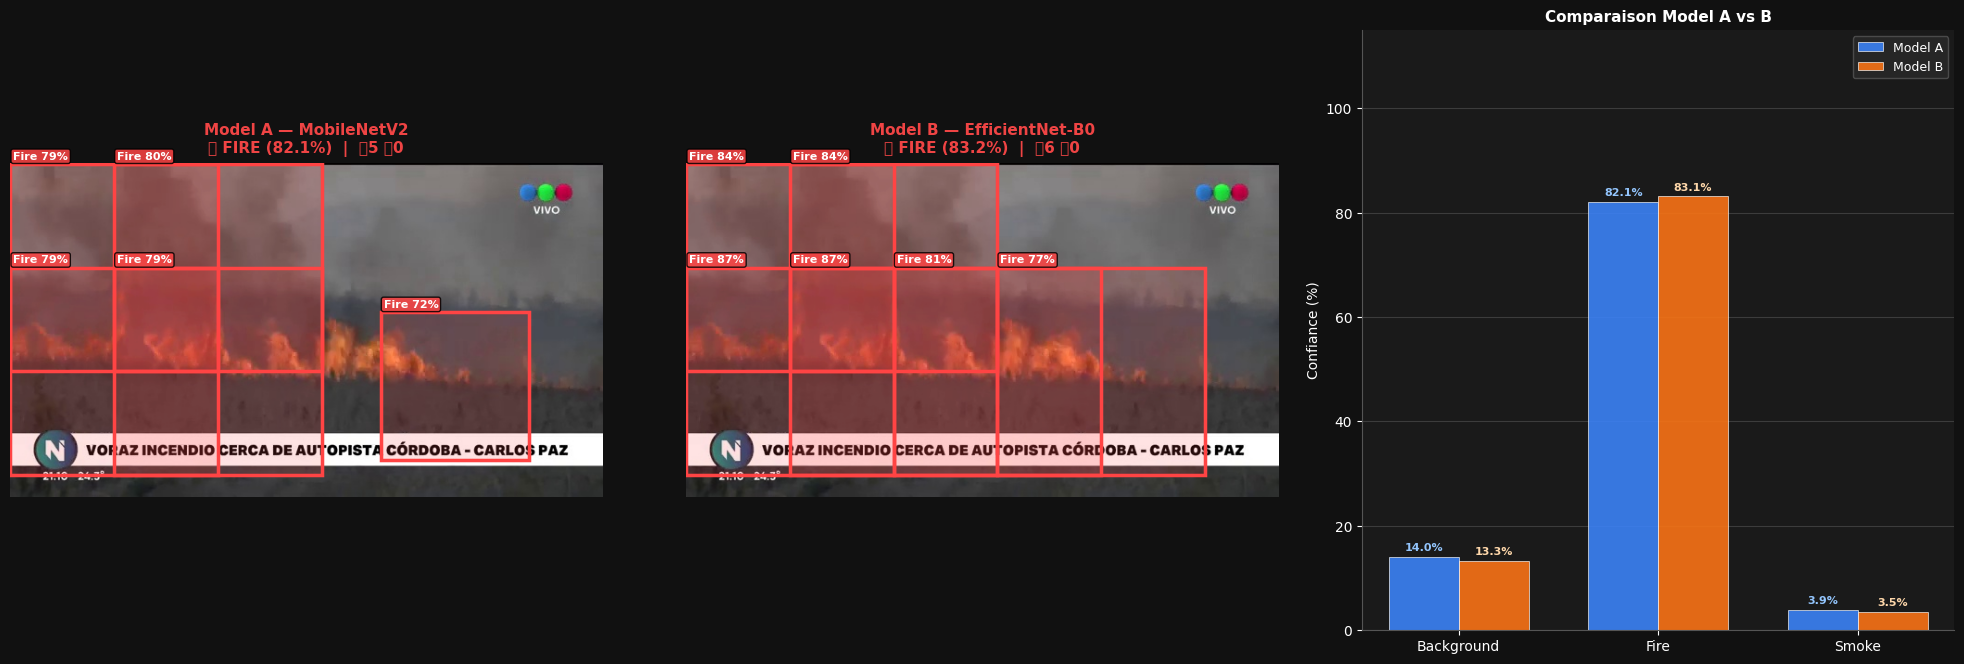

✓ Résultat sauvegardé : /kaggle/working/models/result_WEB05365.png

Pour tester VOTRE image : ajoutez-la dans
  Add data → Upload → choisir un fichier
Puis remplacer img_path ci-dessous :

  img_path = '/kaggle/input/MON-DATASET/image.jpg'
  pil_img  = Image.open(img_path).convert('RGB')
  probs_a  = predict(model_a, pil_img)
  probs_b  = predict(model_b, pil_img)
  dets_a   = nms(sliding_window(model_a, pil_img))
  dets_b   = nms(sliding_window(model_b, pil_img))
  print_report(probs_a, probs_b, dets_a, dets_b)
  visualize(pil_img, dets_a, dets_b, probs_a, probs_b,
            '/kaggle/working/mon_resultat.png')

✓ Partie 6 terminée

Fichiers dans /kaggle/working/models :
  modelA.pkl  (13.7 MB)
  modelA_ep10.pkl  (13.7 MB)
  modelA_ep15.pkl  (13.7 MB)
  modelA_ep20.pkl  (13.7 MB)
  modelA_ep25.pkl  (13.7 MB)
  modelA_ep30.pkl  (13.7 MB)
  modelA_ep35.pkl  (13.7 MB)
  modelA_ep40.pkl  (13.7 MB)
  modelA_ep5.pkl  (13.7 MB)
  modelB.pkl  (21.9 MB)
  modelB_ep10.pkl  (21.9 MB)
  modelB_e

In [12]:
# ============================================================
# PARTIE 6 — INFÉRENCE SUR IMAGE
# Sur Kaggle : uploader une image dans la session
# ou utiliser une image du dataset de test
# ============================================================
import torch
import torch.nn.functional as F
import pickle, os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
from torchvision import transforms

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# ── Charger les modèles ───────────────────────────────────
def load_model(pkl_path, model_class):
    with open(pkl_path, 'rb') as f:
        ckpt = pickle.load(f)
    m = model_class(num_classes=CONFIG['num_classes']).to(DEVICE)
    m.load_state_dict(ckpt['model_state_dict'])
    m.eval()
    acc = ckpt.get('best_val_acc', '?')
    print(f"  ✓ {os.path.basename(pkl_path)} | val acc = {acc}")
    return m

print("Chargement des modèles entraînés...")
model_a = load_model(f"{OUTPUT_DIR}/modelA.pkl", ModelA)
model_b = load_model(f"{OUTPUT_DIR}/modelB.pkl", ModelB)

# ── Transforms inférence ─────────────────────────────────
infer_tf = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

CLASS_NAMES  = ['Background', 'Fire', 'Smoke']
CLASS_EMOJIS = ['🟢', '🔥', '💨']
CLASS_COLORS = ['#22c55e', '#ef4444', '#9ca3af']


# ── Prédiction globale ────────────────────────────────────
@torch.no_grad()
def predict(model, pil_img):
    t = infer_tf(pil_img).unsqueeze(0).to(DEVICE)
    with torch.cuda.amp.autocast():
        logits = model(t)
    probs = F.softmax(logits, dim=-1).squeeze(0).cpu().numpy()
    return probs


# ── Sliding window + NMS ──────────────────────────────────
@torch.no_grad()
def sliding_window(model, pil_img, wins=[224, 160, 96],
                   stride_r=0.5, thresh=0.70):
    W, H = pil_img.size
    norm = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ])
    dets = []
    for ws in wins:
        if ws > min(W, H):
            continue
        stride = max(int(ws * stride_r), 16)
        for y in range(0, H - ws + 1, stride):
            for x in range(0, W - ws + 1, stride):
                crop = pil_img.crop((x, y, x + ws, y + ws))
                t = norm(crop).unsqueeze(0).to(DEVICE)
                with torch.cuda.amp.autocast():
                    logits = model(t)
                probs = F.softmax(logits, dim=-1).squeeze(0)
                conf, cls = probs.max(0)
                conf = conf.item(); cls = cls.item()
                if cls > 0 and conf >= thresh:
                    dets.append((x, y, x + ws, y + ws, cls, conf))
    return dets


def nms(dets, iou_thr=0.35):
    if not dets:
        return []
    boxes  = np.array([[d[0],d[1],d[2],d[3]] for d in dets], float)
    scores = np.array([d[5] for d in dets])
    x1,y1,x2,y2 = boxes[:,0],boxes[:,1],boxes[:,2],boxes[:,3]
    areas  = (x2-x1)*(y2-y1)
    order  = scores.argsort()[::-1]
    kept   = []
    while order.size > 0:
        i = order[0]; kept.append(i)
        xx1 = np.maximum(x1[i], x1[order[1:]])
        yy1 = np.maximum(y1[i], y1[order[1:]])
        xx2 = np.minimum(x2[i], x2[order[1:]])
        yy2 = np.minimum(y2[i], y2[order[1:]])
        iou = (np.maximum(0,xx2-xx1)*np.maximum(0,yy2-yy1)) / \
              (areas[i] + areas[order[1:]] -
               np.maximum(0,xx2-xx1)*np.maximum(0,yy2-yy1) + 1e-6)
        order = order[1:][iou < iou_thr]
    return [dets[i] for i in kept]


# ── Visualisation ─────────────────────────────────────────
def visualize(pil_img, dets_a, dets_b, probs_a, probs_b, save_path):
    fig, axes = plt.subplots(1, 3, figsize=(20, 7))
    fig.patch.set_facecolor('#111111')
    col_map = {1: '#FF4444', 2: '#BBBBBB'}

    for ax, dets, probs, title in zip(
        axes[:2],
        [dets_a, dets_b],
        [probs_a, probs_b],
        ['Model A — MobileNetV2', 'Model B — EfficientNet-B0']
    ):
        ax.imshow(np.array(pil_img))
        ax.set_facecolor('#1a1a1a')
        for (x1,y1,x2,y2,cls,conf) in dets:
            c = col_map.get(cls, '#fff')
            ax.add_patch(patches.Rectangle(
                (x1,y1), x2-x1, y2-y1,
                lw=2.5, edgecolor=c, facecolor=c, alpha=0.15))
            ax.add_patch(patches.Rectangle(
                (x1,y1), x2-x1, y2-y1,
                lw=2.5, edgecolor=c, facecolor='none'))
            ax.text(x1+3, y1-5, f"{CLASS_NAMES[cls]} {conf:.0%}",
                    color='white', fontsize=8, fontweight='bold',
                    bbox=dict(facecolor=c, alpha=0.85,
                              boxstyle='round,pad=0.2'))
        pred = np.argmax(probs)
        tc   = CLASS_COLORS[pred]
        nf   = sum(1 for d in dets if d[4]==1)
        ns   = sum(1 for d in dets if d[4]==2)
        ax.set_title(
            f"{title}\n"
            f"{CLASS_EMOJIS[pred]} {CLASS_NAMES[pred].upper()} "
            f"({probs[pred]:.1%})  |  🔥{nf} 💨{ns}",
            color=tc, fontsize=11, fontweight='bold', pad=8)
        ax.axis('off')

    # ── Graphe de confiance ───────────────────────────────
    ax3 = axes[2]
    ax3.set_facecolor('#1a1a1a')
    x = np.arange(len(CLASS_NAMES)); w = 0.35
    b1 = ax3.bar(x-w/2, probs_a*100, w, label='Model A',
                 color='#3B82F6', alpha=0.9, edgecolor='white', lw=0.5)
    b2 = ax3.bar(x+w/2, probs_b*100, w, label='Model B',
                 color='#F97316', alpha=0.9, edgecolor='white', lw=0.5)
    for bars, fc in [(b1,'#93C5FD'),(b2,'#FED7AA')]:
        for bar in bars:
            h = bar.get_height()
            if h > 2:
                ax3.text(bar.get_x()+bar.get_width()/2, h+0.8,
                         f'{h:.1f}%', ha='center', va='bottom',
                         color=fc, fontsize=8, fontweight='bold')
    ax3.set_xticks(x); ax3.set_xticklabels(CLASS_NAMES, color='white')
    ax3.set_ylim(0, 115); ax3.set_ylabel('Confiance (%)', color='white')
    ax3.set_title('Comparaison Model A vs B',
                  color='white', fontsize=11, fontweight='bold')
    ax3.legend(facecolor='#2a2a2a', edgecolor='#555',
               labelcolor='white', fontsize=9)
    ax3.tick_params(colors='white')
    for sp in ['top','right']: ax3.spines[sp].set_visible(False)
    for sp in ['bottom','left']:
        ax3.spines[sp].set_color('#555')
    ax3.yaxis.grid(True, alpha=0.15, color='white')
    ax3.set_axisbelow(True)

    plt.tight_layout(pad=2)
    plt.savefig(save_path, dpi=150, bbox_inches='tight', facecolor='#111')
    plt.show()
    print(f"✓ Résultat sauvegardé : {save_path}")


def print_report(probs_a, probs_b, dets_a, dets_b):
    print("\n" + "═"*58)
    print("        RAPPORT DE DÉTECTION  —  OnlineKD DML")
    print("═"*58)
    for name, probs, dets in [
        ("MODEL A  MobileNetV2", probs_a, dets_a),
        ("MODEL B  EfficientNet-B0", probs_b, dets_b)
    ]:
        pred = np.argmax(probs)
        print(f"\n  {name}")
        print(f"  {'─'*44}")
        for i,(cls,p) in enumerate(zip(CLASS_NAMES, probs)):
            bar = '█' * int(p*28)
            mk  = ' ◄' if i==pred else ''
            print(f"  {CLASS_EMOJIS[i]} {cls:<12} {bar:<28} {p:.1%}{mk}")
        print(f"\n  Zones détectées : {len(dets)}")
        for d in dets:
            print(f"    → {CLASS_NAMES[d[4]]:10} conf={d[5]:.1%}  "
                  f"bbox=({d[0]},{d[1]})→({d[2]},{d[3]})")
    avg  = (probs_a + probs_b) / 2
    vrd  = np.argmax(avg)
    agr  = np.argmax(probs_a) == np.argmax(probs_b)
    print(f"\n  Accord des modèles  : {'✓ OUI' if agr else '✗ NON'}")
    print(f"  Confiance moyenne   : "
          f"A={probs_a.max():.1%}  B={probs_b.max():.1%}")
    print(f"\n  ▶ VERDICT FINAL (ensemble) : "
          f"{CLASS_EMOJIS[vrd]} {CLASS_NAMES[vrd].upper()} "
          f"({avg[vrd]:.1%})")
    print("═"*58)


# ══════════════════════════════════════════════════════════
#  CHOISIR L'IMAGE À TESTER
# ══════════════════════════════════════════════════════════

# ── Option A : image depuis le dataset de test ────────────
test_images = (
    glob.glob(f"{DATASET_ROOT}/test/images/*.jpg") +
    glob.glob(f"{DATASET_ROOT}/test/images/*.png") +
    glob.glob(f"{DATASET_ROOT}/valid/images/*.jpg") +
    glob.glob(f"{DATASET_ROOT}/**/images/*.jpg", recursive=True)
)

if test_images:
    # Tester les 4 premières images du dataset
    sample_imgs = test_images[:4]
    print(f"Test sur {len(sample_imgs)} images du dataset\n")
else:
    sample_imgs = []
    print("Aucune image de test trouvée dans le dataset")

for img_path in sample_imgs:
    print(f"\n{'─'*50}")
    print(f"Image : {os.path.basename(img_path)}")
    pil_img = Image.open(img_path).convert('RGB')
    W, H    = pil_img.size
    print(f"Taille : {W}×{H}")

    probs_a = predict(model_a, pil_img)
    probs_b = predict(model_b, pil_img)

    dets_a = nms(sliding_window(model_a, pil_img,
                                wins=[min(224,W//2), min(160,W//3)],
                                thresh=0.70))
    dets_b = nms(sliding_window(model_b, pil_img,
                                wins=[min(224,W//2), min(160,W//3)],
                                thresh=0.70))

    print_report(probs_a, probs_b, dets_a, dets_b)

    save_path = (f"{OUTPUT_DIR}/result_"
                 f"{os.path.splitext(os.path.basename(img_path))[0]}.png")
    visualize(pil_img, dets_a, dets_b, probs_a, probs_b, save_path)


# ── Option B : uploader votre propre image ────────────────
print("\n" + "="*50)
print("Pour tester VOTRE image : ajoutez-la dans")
print("  Add data → Upload → choisir un fichier")
print("Puis remplacer img_path ci-dessous :")
print()
print("  img_path = '/kaggle/input/MON-DATASET/image.jpg'")
print("  pil_img  = Image.open(img_path).convert('RGB')")
print("  probs_a  = predict(model_a, pil_img)")
print("  probs_b  = predict(model_b, pil_img)")
print("  dets_a   = nms(sliding_window(model_a, pil_img))")
print("  dets_b   = nms(sliding_window(model_b, pil_img))")
print("  print_report(probs_a, probs_b, dets_a, dets_b)")
print("  visualize(pil_img, dets_a, dets_b, probs_a, probs_b,")
print("            '/kaggle/working/mon_resultat.png')")

print("\n✓ Partie 6 terminée")
print(f"\nFichiers dans {OUTPUT_DIR} :")
for f in sorted(os.listdir(OUTPUT_DIR)):
    size = os.path.getsize(f"{OUTPUT_DIR}/{f}") / 1e6
    print(f"  {f}  ({size:.1f} MB)")
print("Exixte")

#Pour telecharge en locale 

In [13]:
import os

# Voir tous les fichiers sauvegardés
print("=== Fichiers dans /kaggle/working/ ===\n")
for root, dirs, files in os.walk('/kaggle/working'):
    for f in files:
        full_path = os.path.join(root, f)
        size = os.path.getsize(full_path) / 1e6
        print(f"  {full_path}  ({size:.1f} MB)")

print("Exicte")

=== Fichiers dans /kaggle/working/ ===

  /kaggle/working/models/modelA_ep40.pkl  (13.7 MB)
  /kaggle/working/models/modelA_ep30.pkl  (13.7 MB)
  /kaggle/working/models/result_WEB05194.png  (0.5 MB)
  /kaggle/working/models/modelB_ep25.pkl  (21.9 MB)
  /kaggle/working/models/modelB_ep15.pkl  (21.9 MB)
  /kaggle/working/models/result_AoF04660.png  (0.2 MB)
  /kaggle/working/models/modelB_ep5.pkl  (21.9 MB)
  /kaggle/working/models/modelB_ep40.pkl  (21.9 MB)
  /kaggle/working/models/modelB_ep10.pkl  (21.9 MB)
  /kaggle/working/models/modelA_ep20.pkl  (13.7 MB)
  /kaggle/working/models/modelA_ep5.pkl  (13.7 MB)
  /kaggle/working/models/modelB.pkl  (21.9 MB)
  /kaggle/working/models/result_AoF04762.png  (0.2 MB)
  /kaggle/working/models/modelA_ep25.pkl  (13.7 MB)
  /kaggle/working/models/modelA_ep35.pkl  (13.7 MB)
  /kaggle/working/models/modelB_ep30.pkl  (21.9 MB)
  /kaggle/working/models/modelA_ep10.pkl  (13.7 MB)
  /kaggle/working/models/modelB_ep20.pkl  (21.9 MB)
  /kaggle/working/mode

#**valisation compete+matrice de confusion**

In [16]:
# ============================================================
# PARTIE 7 — VALIDATION COMPLÈTE
# Matrice de confusion + Métriques détaillées par classe
# Comparaison Model A vs Model B vs Ensemble
# ============================================================
import torch
import torch.nn.functional as F
import pickle, os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.metrics import (
    confusion_matrix, classification_report,
    roc_auc_score, roc_curve, precision_recall_curve,
    average_precision_score, cohen_kappa_score,
    matthews_corrcoef, f1_score
)
from sklearn.preprocessing import label_binarize
import seaborn as sns
from torch.cuda.amp import autocast

DEVICE      = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
CLASS_NAMES = ['Fire', 'Smoke']
OUTPUT_DIR  = '/kaggle/working/models'

# ── Charger les modèles ───────────────────────────────────
def load_model(pkl_path, model_class):
    with open(pkl_path, 'rb') as f:
        ckpt = pickle.load(f)
    m = model_class(num_classes=3).to(DEVICE)
    m.load_state_dict(ckpt['model_state_dict'])
    m.eval()
    return m, ckpt

model_a, ckpt_a = load_model(f"{OUTPUT_DIR}/modelA.pkl", ModelA)
model_b, ckpt_b = load_model(f"{OUTPUT_DIR}/modelB.pkl", ModelB)
print("✓ Modèles chargés")


# ── Collecte des prédictions sur le test set ──────────────
@torch.no_grad()
def collect_predictions(model, loader):
    all_labels, all_preds, all_probs = [], [], []
    for imgs, labels in loader:
        imgs   = imgs.to(DEVICE, non_blocking=True)
        labels = labels.to(DEVICE, non_blocking=True)
        with autocast():
            logits = model(imgs)
        probs  = F.softmax(logits, dim=-1)
        preds  = probs.argmax(dim=1)
        all_labels.append(labels.cpu().numpy())
        all_preds.append(preds.cpu().numpy())
        all_probs.append(probs.cpu().numpy())
    return (np.concatenate(all_labels),
            np.concatenate(all_preds),
            np.concatenate(all_probs))

print("Collecte des prédictions sur le test set...")
y_true,  preds_a, probs_a = collect_predictions(model_a, test_loader)
_,       preds_b, probs_b = collect_predictions(model_b, test_loader)

# Prédictions ensemble (moyenne des probabilités)
probs_ens  = (probs_a + probs_b) / 2
preds_ens  = probs_ens.argmax(axis=1)

print(f"Échantillons test : {len(y_true)}")
print(f"Distribution réelle : "
      f"{dict(zip(*np.unique(y_true, return_counts=True)))}")


# ── Calcul des métriques complètes ────────────────────────
def compute_metrics(y_true, y_pred, y_prob, name):
    n_classes = len(CLASS_NAMES)
    y_bin     = label_binarize(y_true, classes=list(range(n_classes)))
    acc       = (y_pred == y_true).mean() * 100
    report    = classification_report(
                    y_true, y_pred,
                    target_names=CLASS_NAMES,
                    output_dict=True, zero_division=0)
    kappa     = cohen_kappa_score(y_true, y_pred)
    mcc       = matthews_corrcoef(y_true, y_pred)
    macro_f1  = f1_score(y_true, y_pred, average='macro',  zero_division=0)
    weighted_f1 = f1_score(y_true, y_pred, average='weighted', zero_division=0)
    try:
        auc_ovr = roc_auc_score(y_bin, y_prob,
                                multi_class='ovr', average='macro')
    except Exception:
        auc_ovr = float('nan')

    print(f"\n{'═'*56}")
    print(f"  {name}")
    print(f"{'═'*56}")
    print(f"  Accuracy          : {acc:.2f}%")
    print(f"  Macro F1-score    : {macro_f1:.4f}")
    print(f"  Weighted F1-score : {weighted_f1:.4f}")
    print(f"  Cohen Kappa       : {kappa:.4f}")
    print(f"  Matthews MCC      : {mcc:.4f}")
    print(f"  ROC-AUC (OvR)     : {auc_ovr:.4f}")
    print(f"\n  Par classe :")
    print(f"  {'Classe':<12} {'Précision':>10} {'Rappel':>8} "
          f"{'F1':>8} {'Support':>9}")
    print(f"  {'─'*50}")
    for cls in CLASS_NAMES:
        r = report[cls]
        print(f"  {cls:<12} {r['precision']:>10.4f} {r['recall']:>8.4f} "
              f"{r['f1-score']:>8.4f} {int(r['support']):>9}")
    return {
        'acc': acc, 'macro_f1': macro_f1,
        'weighted_f1': weighted_f1, 'kappa': kappa,
        'mcc': mcc, 'auc': auc_ovr, 'report': report
    }

metrics_a   = compute_metrics(y_true, preds_a,   probs_a,   "MODEL A — MobileNetV2")
metrics_b   = compute_metrics(y_true, preds_b,   probs_b,   "MODEL B — EfficientNet-B0")
metrics_ens = compute_metrics(y_true, preds_ens, probs_ens, "ENSEMBLE (A + B) / 2")

print("matric")

✓ Modèles chargés
Collecte des prédictions sur le test set...
Échantillons test : 3230
Distribution réelle : {np.int64(0): np.int64(2642), np.int64(1): np.int64(588)}

════════════════════════════════════════════════════════
  MODEL A — MobileNetV2
════════════════════════════════════════════════════════
  Accuracy          : 94.67%
  Macro F1-score    : 0.9121
  Weighted F1-score : 0.9472
  Cohen Kappa       : 0.8242
  Matthews MCC      : 0.8245
  ROC-AUC (OvR)     : nan

  Par classe :
  Classe        Précision   Rappel       F1   Support
  ──────────────────────────────────────────────────
  Fire             0.9721   0.9625   0.9673      2642
  Smoke            0.8388   0.8759   0.8569       588

════════════════════════════════════════════════════════
  MODEL B — EfficientNet-B0
════════════════════════════════════════════════════════
  Accuracy          : 94.71%
  Macro F1-score    : 0.9133
  Weighted F1-score : 0.9477
  Cohen Kappa       : 0.8267
  Matthews MCC      : 0.8273
  RO

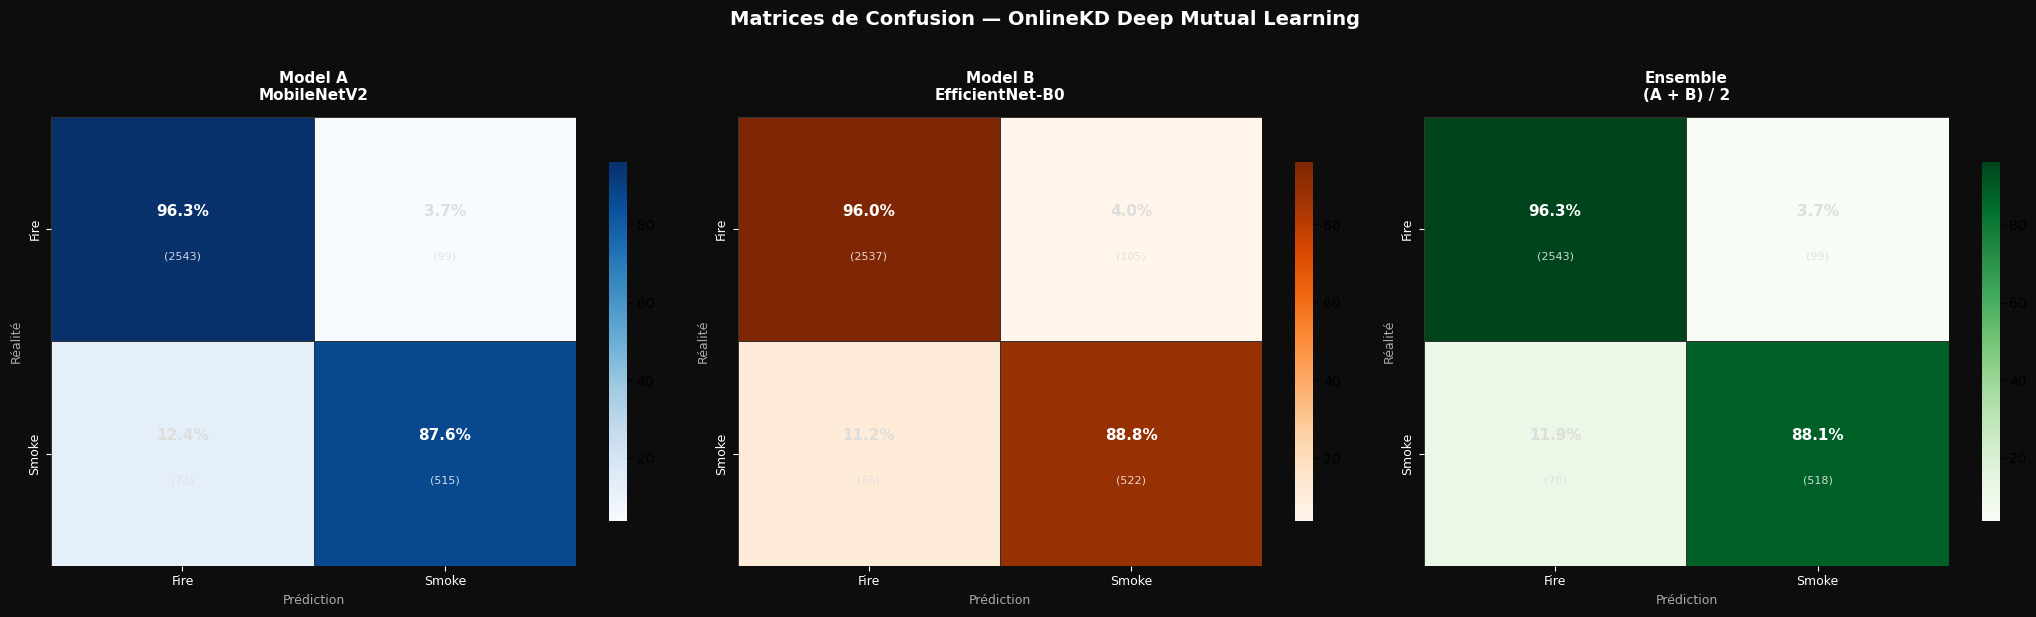

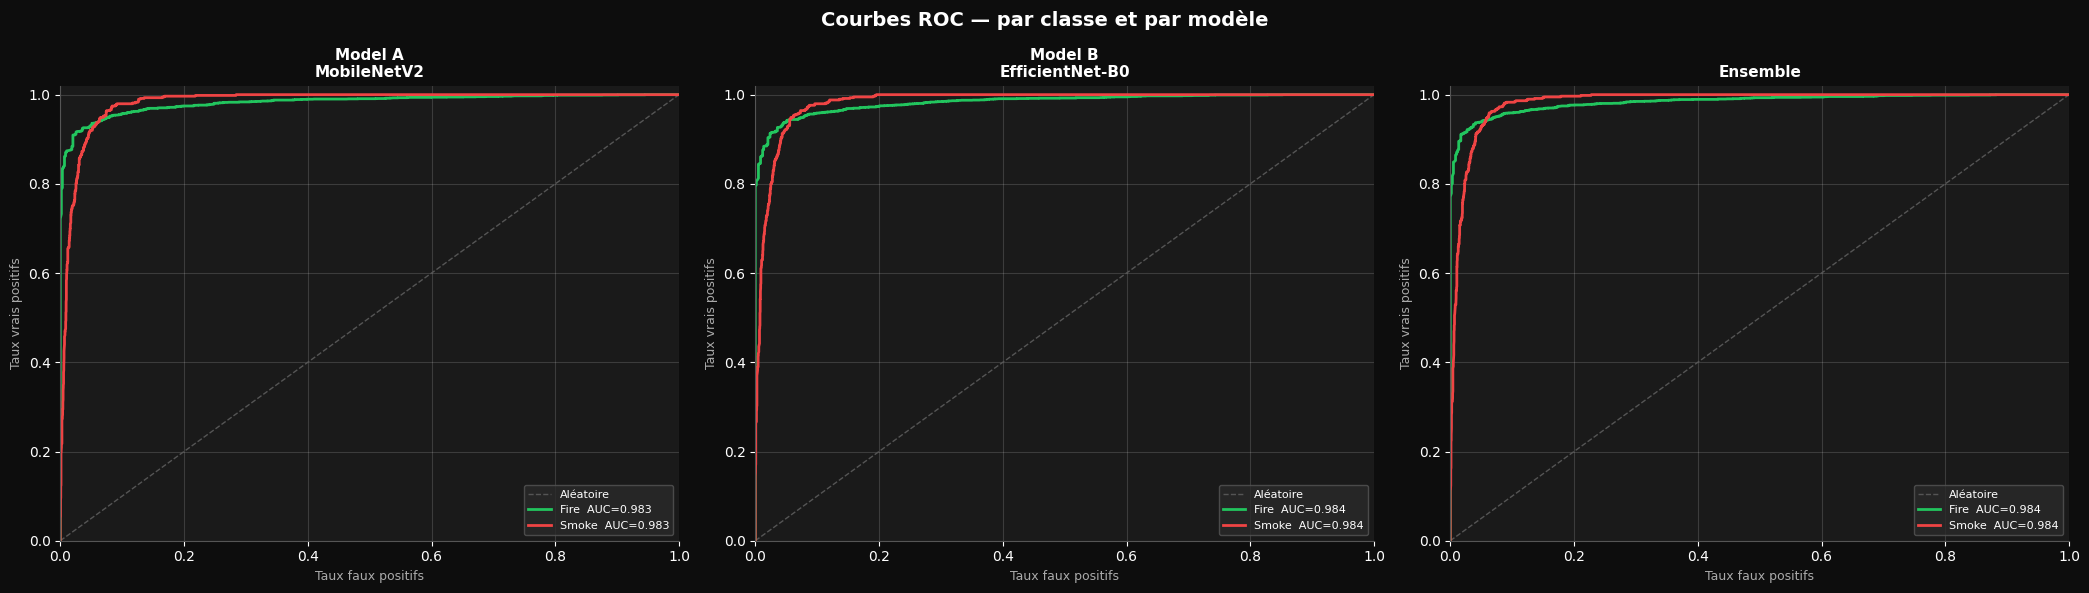

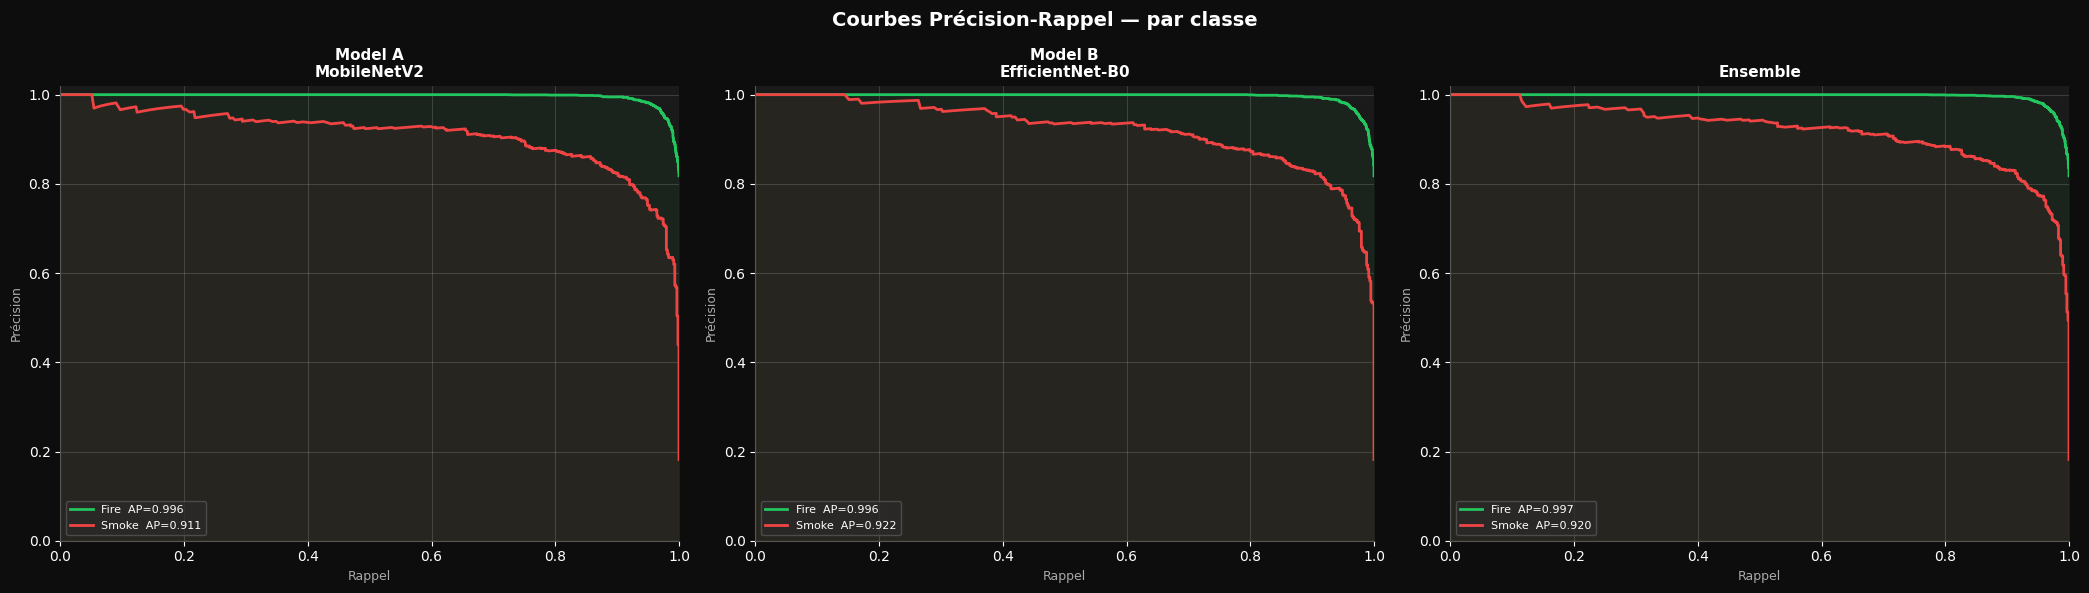

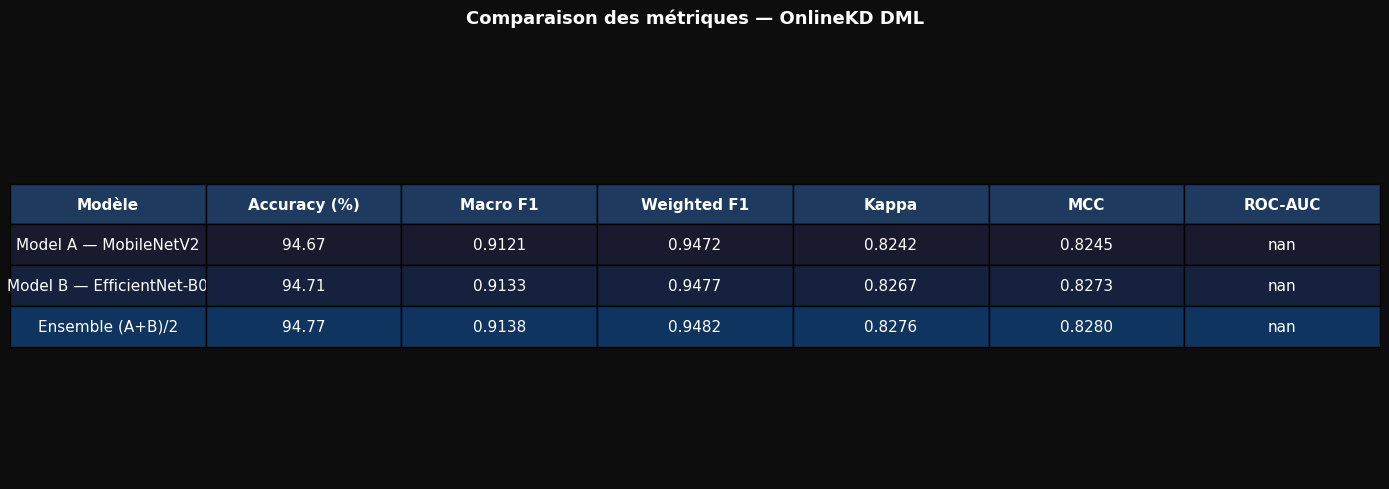


✓ Partie 7 terminée
Fichiers sauvegardés dans /kaggle/working/models :
  → confusion_matrices.png
  → roc_curves.png
  → pr_curves.png
  → metrics_table.png
bien test


In [17]:

# ── Figure 1 : Matrices de confusion ─────────────────────
fig, axes = plt.subplots(1, 3, figsize=(21, 6))
fig.patch.set_facecolor('#0d0d0d')
fig.suptitle('Matrices de Confusion — OnlineKD Deep Mutual Learning',
             color='white', fontsize=14, fontweight='bold', y=1.02)

titles  = ['Model A\nMobileNetV2', 'Model B\nEfficientNet-B0', 'Ensemble\n(A + B) / 2']
preds_l = [preds_a, preds_b, preds_ens]
cmaps   = ['Blues', 'Oranges', 'Greens']

for ax, title, preds, cmap in zip(axes, titles, preds_l, cmaps):
    cm   = confusion_matrix(y_true, preds)
    cm_n = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100

    sns.heatmap(cm_n, annot=False, fmt='', cmap=cmap,
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
                ax=ax, linewidths=0.5, linecolor='#333',
                cbar_kws={'shrink': 0.8})

    # Annotations personnalisées : % + nb brut
    for i in range(len(CLASS_NAMES)):
        for j in range(len(CLASS_NAMES)):
            val_pct = cm_n[i, j]
            val_raw = cm[i, j]
            color   = 'white' if val_pct > 50 else '#dddddd'
            ax.text(j + 0.5, i + 0.42,
                    f'{val_pct:.1f}%',
                    ha='center', va='center',
                    color=color, fontsize=11, fontweight='bold')
            ax.text(j + 0.5, i + 0.62,
                    f'({val_raw})',
                    ha='center', va='center',
                    color=color, fontsize=8, alpha=0.8)

    ax.set_title(title, color='white', fontsize=11,
                 fontweight='bold', pad=12)
    ax.set_xlabel('Prédiction', color='#aaaaaa', fontsize=9)
    ax.set_ylabel('Réalité',    color='#aaaaaa', fontsize=9)
    ax.tick_params(colors='white', labelsize=9)
    ax.set_facecolor('#1a1a1a')
    for sp in ax.spines.values():
        sp.set_edgecolor('#444')

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/confusion_matrices.png',
            dpi=150, bbox_inches='tight', facecolor='#0d0d0d')
plt.show()


# ── Figure 2 : Courbes ROC multi-classes ─────────────────
fig, axes = plt.subplots(1, 3, figsize=(21, 6))
fig.patch.set_facecolor('#0d0d0d')
fig.suptitle('Courbes ROC — par classe et par modèle',
             color='white', fontsize=14, fontweight='bold')

y_bin      = label_binarize(y_true, classes=[0, 1, 2])
colors_roc = ['#22c55e', '#ef4444', '#9ca3af']

for ax, name, probs in zip(
    axes,
    ['Model A\nMobileNetV2', 'Model B\nEfficientNet-B0', 'Ensemble'],
    [probs_a, probs_b, probs_ens]
):
    ax.set_facecolor('#1a1a1a')
    ax.plot([0,1],[0,1], '--', color='#555555', lw=1, label='Aléatoire')

    for i, (cls, col) in enumerate(zip(CLASS_NAMES, colors_roc)):
        fpr, tpr, _ = roc_curve(y_bin[:, i], probs[:, i])
        try:
            auc = roc_auc_score(y_bin[:, i], probs[:, i])
        except Exception:
            auc = float('nan')
        ax.plot(fpr, tpr, color=col, lw=2,
                label=f'{cls}  AUC={auc:.3f}')

    ax.set_xlabel('Taux faux positifs', color='#aaaaaa', fontsize=9)
    ax.set_ylabel('Taux vrais positifs', color='#aaaaaa', fontsize=9)
    ax.set_title(name, color='white', fontsize=11, fontweight='bold')
    ax.legend(facecolor='#2a2a2a', edgecolor='#555',
              labelcolor='white', fontsize=8)
    ax.tick_params(colors='white')
    ax.set_xlim([0, 1]); ax.set_ylim([0, 1.02])
    for sp in ['top','right']: ax.spines[sp].set_visible(False)
    for sp in ['bottom','left']: ax.spines[sp].set_color('#555')
    ax.yaxis.grid(True, alpha=0.15, color='white')
    ax.xaxis.grid(True, alpha=0.15, color='white')

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/roc_curves.png',
            dpi=150, bbox_inches='tight', facecolor='#0d0d0d')
plt.show()


# ── Figure 3 : Courbes Précision-Rappel ──────────────────
fig, axes = plt.subplots(1, 3, figsize=(21, 6))
fig.patch.set_facecolor('#0d0d0d')
fig.suptitle('Courbes Précision-Rappel — par classe',
             color='white', fontsize=14, fontweight='bold')

for ax, name, probs in zip(
    axes,
    ['Model A\nMobileNetV2', 'Model B\nEfficientNet-B0', 'Ensemble'],
    [probs_a, probs_b, probs_ens]
):
    ax.set_facecolor('#1a1a1a')
    for i, (cls, col) in enumerate(zip(CLASS_NAMES, colors_roc)):
        prec, rec, _ = precision_recall_curve(y_bin[:, i], probs[:, i])
        ap = average_precision_score(y_bin[:, i], probs[:, i])
        ax.plot(rec, prec, color=col, lw=2,
                label=f'{cls}  AP={ap:.3f}')
        ax.fill_between(rec, prec, alpha=0.06, color=col)

    ax.set_xlabel('Rappel',    color='#aaaaaa', fontsize=9)
    ax.set_ylabel('Précision', color='#aaaaaa', fontsize=9)
    ax.set_title(name, color='white', fontsize=11, fontweight='bold')
    ax.legend(facecolor='#2a2a2a', edgecolor='#555',
              labelcolor='white', fontsize=8)
    ax.tick_params(colors='white')
    ax.set_xlim([0, 1]); ax.set_ylim([0, 1.02])
    for sp in ['top','right']: ax.spines[sp].set_visible(False)
    for sp in ['bottom','left']: ax.spines[sp].set_color('#555')
    ax.yaxis.grid(True, alpha=0.15, color='white')
    ax.xaxis.grid(True, alpha=0.15, color='white')

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/pr_curves.png',
            dpi=150, bbox_inches='tight', facecolor='#0d0d0d')
plt.show()


# ── Figure 4 : Tableau comparatif des métriques ──────────
fig, ax = plt.subplots(figsize=(14, 5))
fig.patch.set_facecolor('#0d0d0d')
ax.set_facecolor('#0d0d0d')
ax.axis('off')

metric_names = ['Accuracy (%)', 'Macro F1',
                'Weighted F1', 'Kappa', 'MCC', 'ROC-AUC']
rows = [
    ['Model A — MobileNetV2',
     f"{metrics_a['acc']:.2f}",
     f"{metrics_a['macro_f1']:.4f}",
     f"{metrics_a['weighted_f1']:.4f}",
     f"{metrics_a['kappa']:.4f}",
     f"{metrics_a['mcc']:.4f}",
     f"{metrics_a['auc']:.4f}"],
    ['Model B — EfficientNet-B0',
     f"{metrics_b['acc']:.2f}",
     f"{metrics_b['macro_f1']:.4f}",
     f"{metrics_b['weighted_f1']:.4f}",
     f"{metrics_b['kappa']:.4f}",
     f"{metrics_b['mcc']:.4f}",
     f"{metrics_b['auc']:.4f}"],
    ['Ensemble (A+B)/2',
     f"{metrics_ens['acc']:.2f}",
     f"{metrics_ens['macro_f1']:.4f}",
     f"{metrics_ens['weighted_f1']:.4f}",
     f"{metrics_ens['kappa']:.4f}",
     f"{metrics_ens['mcc']:.4f}",
     f"{metrics_ens['auc']:.4f}"],
]
col_labels = ['Modèle'] + metric_names
table = ax.table(
    cellText   = rows,
    colLabels  = col_labels,
    loc        = 'center',
    cellLoc    = 'center'
)
table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1, 2.2)

# Style header
for j in range(len(col_labels)):
    table[(0, j)].set_facecolor('#1e3a5f')
    table[(0, j)].set_text_props(color='white', fontweight='bold')

# Style lignes
row_colors = ['#1a1a2e', '#16213e', '#0f3460']
for i, row_color in enumerate(row_colors, start=1):
    for j in range(len(col_labels)):
        table[(i, j)].set_facecolor(row_color)
        table[(i, j)].set_text_props(color='white')

ax.set_title('Comparaison des métriques — OnlineKD DML',
             color='white', fontsize=13, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/metrics_table.png',
            dpi=150, bbox_inches='tight', facecolor='#0d0d0d')
plt.show()

print("\n✓ Partie 7 terminée")
print(f"Fichiers sauvegardés dans {OUTPUT_DIR} :")
for f in ['confusion_matrices.png','roc_curves.png',
          'pr_curves.png','metrics_table.png']:
    print(f"  → {f}")

print("bien test")

#Visualisation des donnes 

Calcul de la distribution des classes...


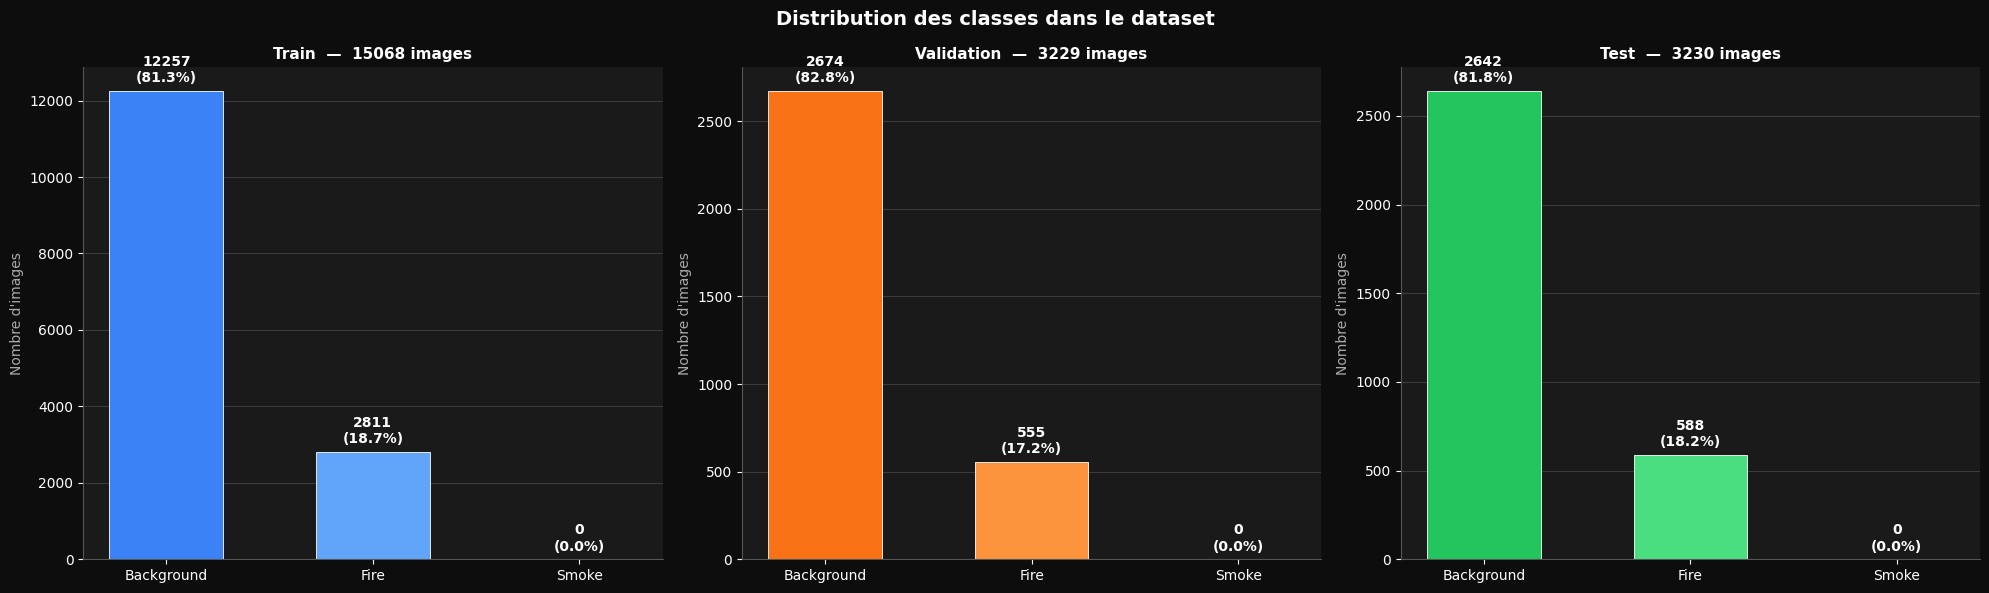

Affichage des exemples d'images par classe...


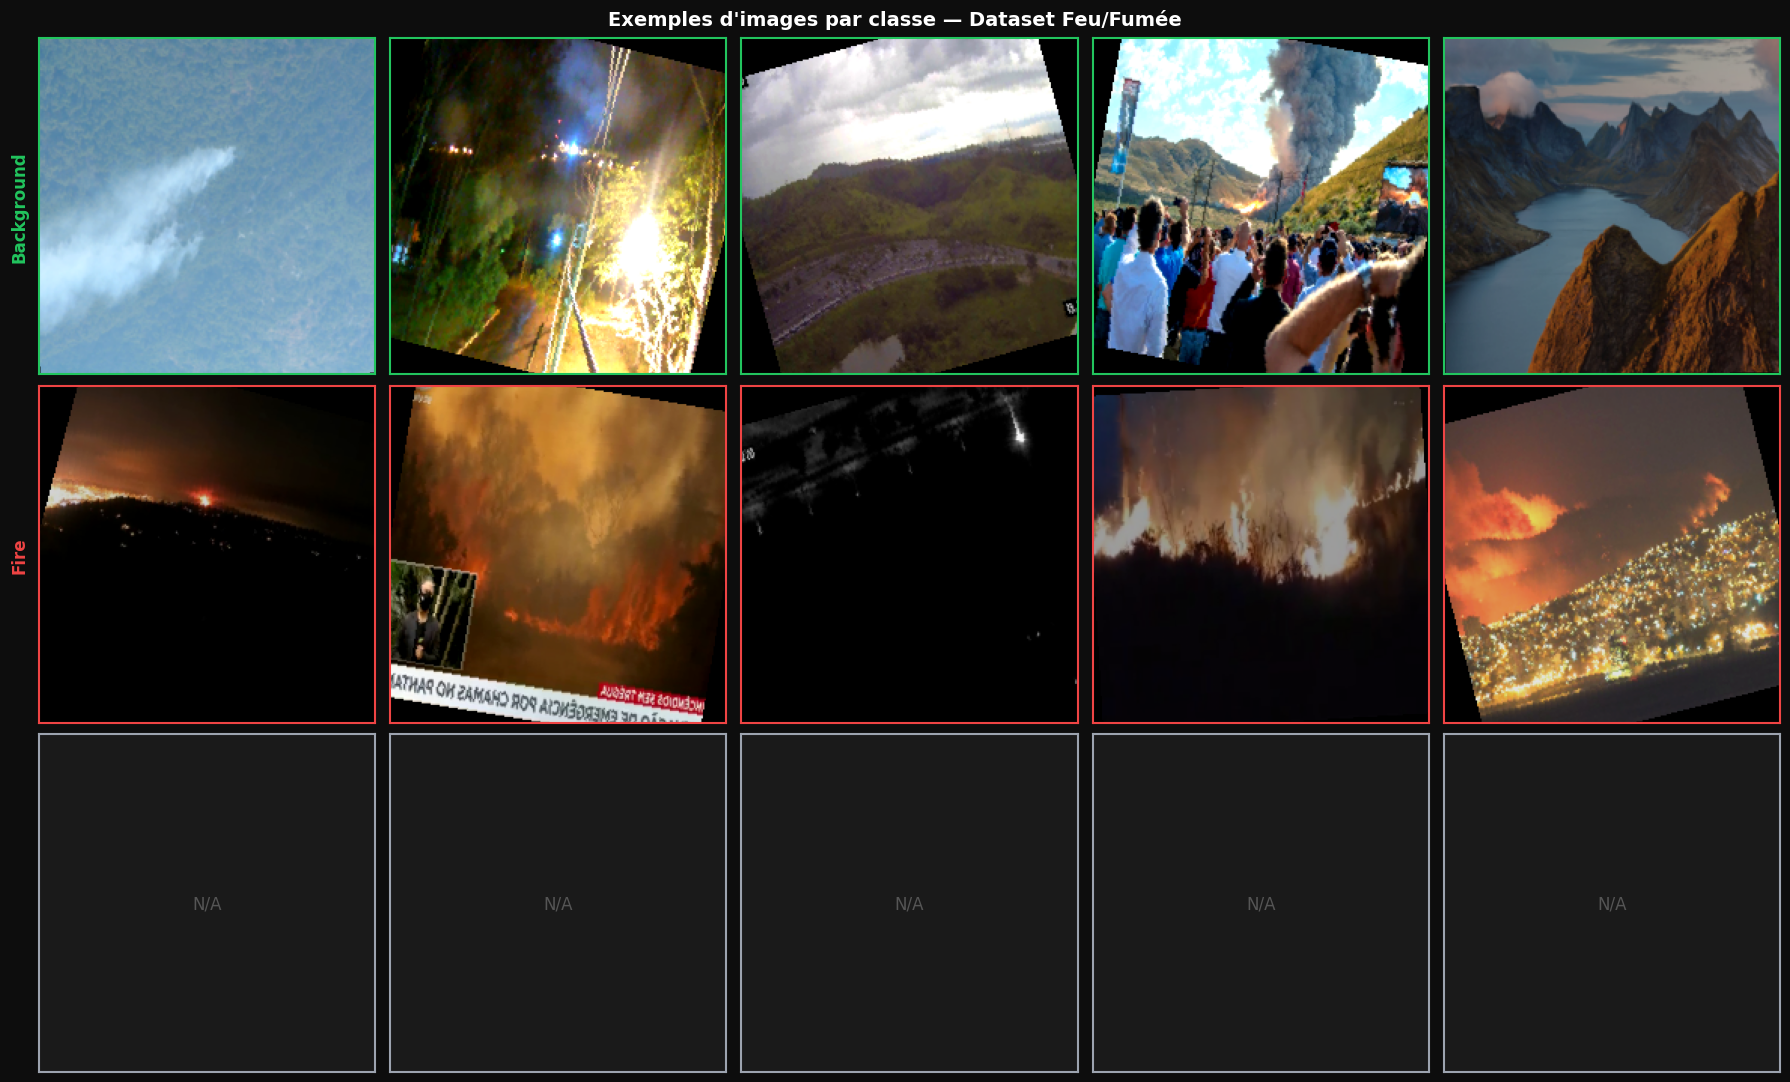

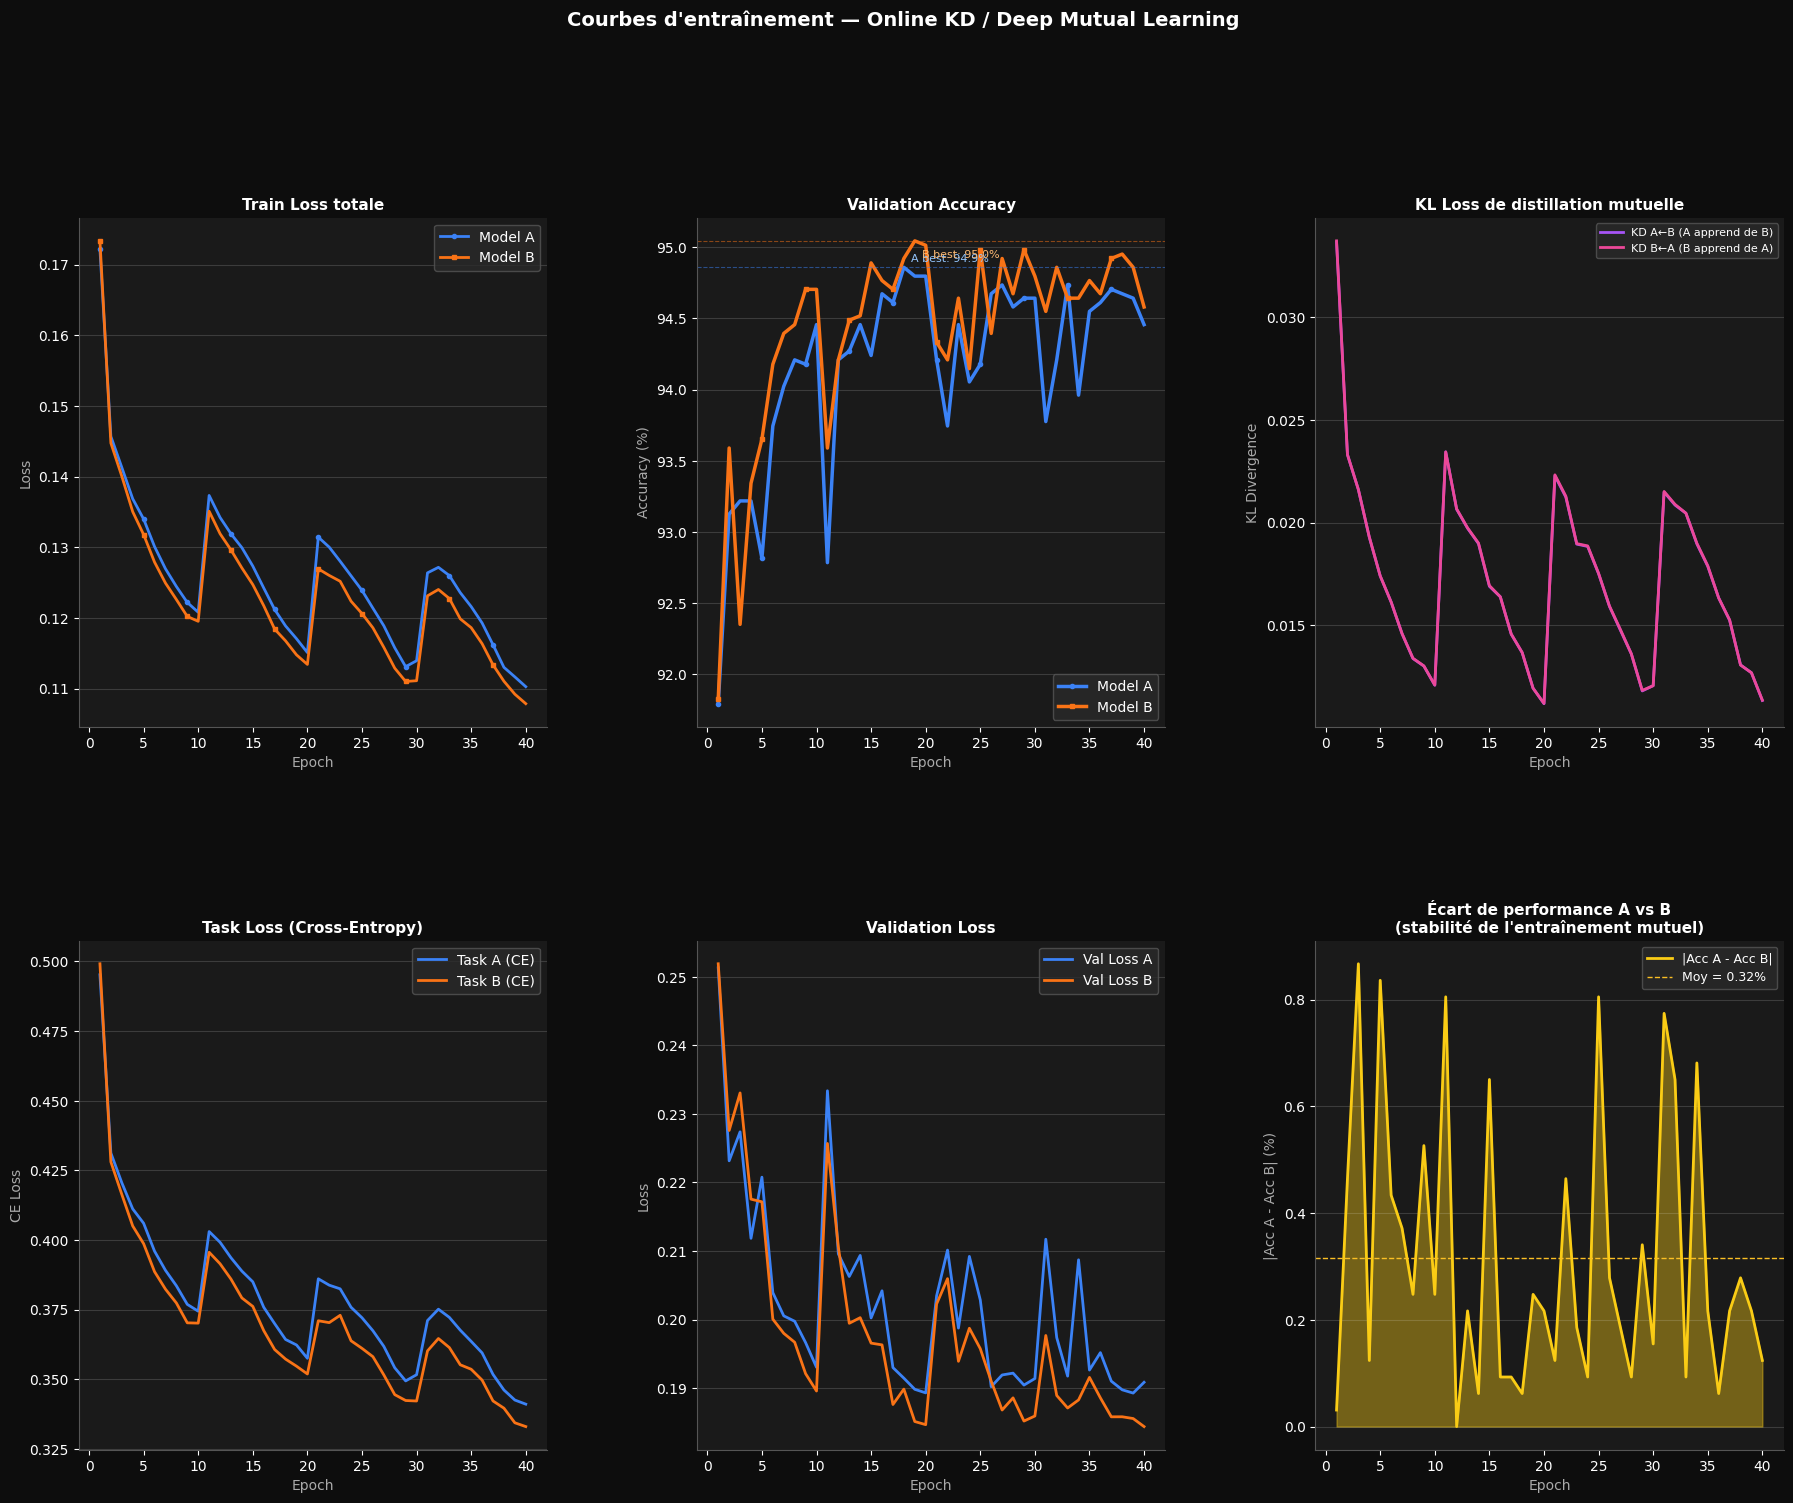

✓ Courbes d'entraînement sauvegardées

Analyse des erreurs de prédiction...


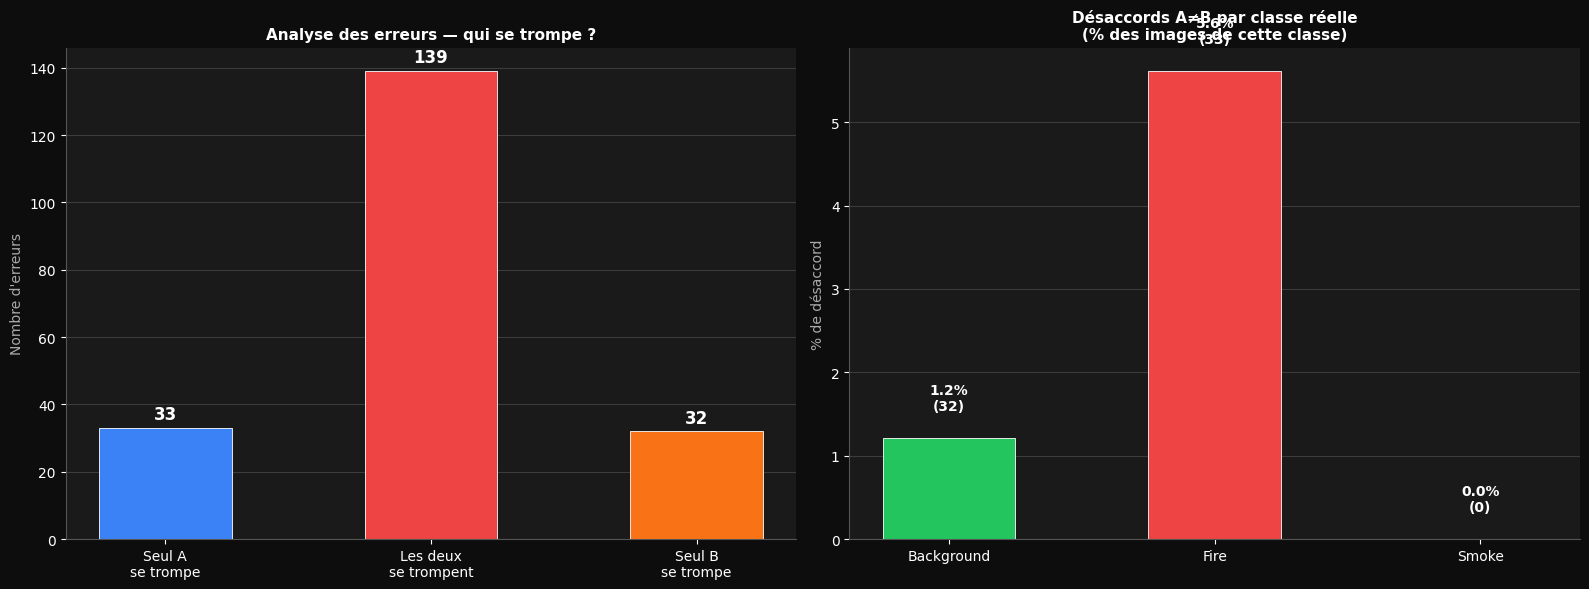


══════════════════════════════════════════════════════════
  RÉSUMÉ FINAL — ANALYSE COMPLÈTE
══════════════════════════════════════════════════════════
  Echantillons test     : 3230
  Désaccords A≠B        : 65 (2.0%)
  Erreurs seul A        : 33
  Erreurs seul B        : 32
  Erreurs des deux      : 139

  Fichiers générés :
  ✓ confusion_matrices.png
  ✓ roc_curves.png
  ✓ pr_curves.png
  ✓ metrics_table.png
  ✓ class_distribution.png
  ✓ sample_images.png
  ✓ training_curves.png
  ✓ error_analysis.png

✓ Partie 8 terminée — Toutes les visualisations disponibles
  → Onglet Output de Kaggle pour télécharger


In [18]:
# ============================================================
# PARTIE 8 — VISUALISATION DES DONNÉES ET DE L'ENTRAÎNEMENT
# Distribution dataset / exemples / courbes loss & accuracy
# ============================================================
import torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from torchvision import transforms
from collections import Counter
import random, os

OUTPUT_DIR  = '/kaggle/working/models'
CLASS_NAMES = ['Background', 'Fire', 'Smoke']
COLORS      = ['#22c55e', '#ef4444', '#9ca3af']

# Récupérer l'historique depuis le pkl
with open(f"{OUTPUT_DIR}/modelA.pkl", 'rb') as f:
    ckpt = pickle.load(f)
history = ckpt.get('history', None)


# ── Figure 1 : Distribution des classes ──────────────────
print("Calcul de la distribution des classes...")

def count_classes(dataset, num_classes=3):
    counts = Counter()
    for _, label in dataset:
        counts[label.item()] += 1
    return [counts[i] for i in range(num_classes)]

train_counts = count_classes(train_dataset)
val_counts   = count_classes(val_dataset)
test_counts  = count_classes(test_dataset)

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.patch.set_facecolor('#0d0d0d')
fig.suptitle('Distribution des classes dans le dataset',
             color='white', fontsize=14, fontweight='bold')

split_names  = ['Train', 'Validation', 'Test']
split_counts = [train_counts, val_counts, test_counts]
split_colors = [['#3B82F6','#60A5FA','#93C5FD'],
                ['#F97316','#FB923C','#FDBA74'],
                ['#22c55e','#4ade80','#86efac']]

for ax, name, counts, cols in zip(
    axes, split_names, split_counts, split_colors
):
    ax.set_facecolor('#1a1a1a')
    total  = sum(counts)
    bars   = ax.bar(CLASS_NAMES, counts,
                    color=cols, edgecolor='white',
                    linewidth=0.6, width=0.55)

    for bar, count in zip(bars, counts):
        pct = count / total * 100
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + total * 0.01,
                f'{count}\n({pct:.1f}%)',
                ha='center', va='bottom',
                color='white', fontsize=10, fontweight='bold')

    ax.set_title(f'{name}  —  {total} images',
                 color='white', fontsize=11, fontweight='bold')
    ax.set_ylabel('Nombre d\'images', color='#aaaaaa')
    ax.tick_params(colors='white')
    ax.set_facecolor('#1a1a1a')
    for sp in ['top','right']: ax.spines[sp].set_visible(False)
    for sp in ['bottom','left']: ax.spines[sp].set_color('#555')
    ax.yaxis.grid(True, alpha=0.15, color='white')
    ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/class_distribution.png',
            dpi=150, bbox_inches='tight', facecolor='#0d0d0d')
plt.show()


# ── Figure 2 : Exemples d'images par classe ──────────────
print("Affichage des exemples d'images par classe...")

# Collecter 5 exemples par classe
examples = {0: [], 1: [], 2: []}
for idx in range(len(train_dataset)):
    img, label = train_dataset[idx]
    cls = label.item()
    if len(examples[cls]) < 5:
        examples[cls].append(img)
    if all(len(v) >= 5 for v in examples.values()):
        break

# Dénormaliser pour affichage
mean = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
std  = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1)

def denorm(t):
    img = t * std + mean
    img = img.permute(1, 2, 0).numpy()
    return np.clip(img, 0, 1)

fig, axes = plt.subplots(3, 5, figsize=(18, 11))
fig.patch.set_facecolor('#0d0d0d')
fig.suptitle('Exemples d\'images par classe — Dataset Feu/Fumée',
             color='white', fontsize=14, fontweight='bold')

header_colors = ['#166534', '#7f1d1d', '#374151']

for row, (cls_idx, cls_name) in enumerate(enumerate(CLASS_NAMES)):
    for col in range(5):
        ax = axes[row][col]
        ax.set_facecolor('#1a1a1a')
        if col < len(examples[cls_idx]):
            img = denorm(examples[cls_idx][col])
            ax.imshow(img)
            if col == 0:
                ax.set_ylabel(cls_name, color=COLORS[cls_idx],
                              fontsize=12, fontweight='bold',
                              rotation=90, labelpad=8)
        else:
            ax.text(0.5, 0.5, 'N/A', color='#555',
                    ha='center', va='center',
                    transform=ax.transAxes, fontsize=12)
        ax.set_xticks([]); ax.set_yticks([])
        for sp in ax.spines.values():
            sp.set_edgecolor(COLORS[cls_idx])
            sp.set_linewidth(1.5)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/sample_images.png',
            dpi=150, bbox_inches='tight', facecolor='#0d0d0d')
plt.show()


# ── Figure 3 : Courbes d'entraînement ─────────────────────
if history:
    epochs = range(1, len(history['train_loss_a']) + 1)

    fig = plt.figure(figsize=(22, 16))
    fig.patch.set_facecolor('#0d0d0d')
    gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.42, wspace=0.32)

    # ── 3a : Train Loss ───────────────────────────────────
    ax1 = fig.add_subplot(gs[0, 0])
    ax1.set_facecolor('#1a1a1a')
    ax1.plot(epochs, history['train_loss_a'],
             color='#3B82F6', lw=2, label='Model A', marker='o',
             markersize=3, markevery=max(1, len(epochs)//10))
    ax1.plot(epochs, history['train_loss_b'],
             color='#F97316', lw=2, label='Model B', marker='s',
             markersize=3, markevery=max(1, len(epochs)//10))
    ax1.set_title('Train Loss totale', color='white',
                  fontsize=11, fontweight='bold')
    ax1.set_xlabel('Epoch', color='#aaa'); ax1.set_ylabel('Loss', color='#aaa')
    ax1.legend(facecolor='#2a2a2a', edgecolor='#555', labelcolor='white')
    ax1.tick_params(colors='white')
    for sp in ['top','right']: ax1.spines[sp].set_visible(False)
    for sp in ['bottom','left']: ax1.spines[sp].set_color('#555')
    ax1.yaxis.grid(True, alpha=0.15, color='white')

    # ── 3b : Validation Accuracy ──────────────────────────
    ax2 = fig.add_subplot(gs[0, 1])
    ax2.set_facecolor('#1a1a1a')
    ax2.plot(epochs, history['val_acc_a'],
             color='#3B82F6', lw=2.5, label='Model A', marker='o',
             markersize=3, markevery=max(1, len(epochs)//10))
    ax2.plot(epochs, history['val_acc_b'],
             color='#F97316', lw=2.5, label='Model B', marker='s',
             markersize=3, markevery=max(1, len(epochs)//10))
    best_a = max(history['val_acc_a'])
    best_b = max(history['val_acc_b'])
    ep_a   = history['val_acc_a'].index(best_a) + 1
    ep_b   = history['val_acc_b'].index(best_b) + 1
    ax2.axhline(best_a, color='#3B82F6', ls='--', lw=0.8, alpha=0.5)
    ax2.axhline(best_b, color='#F97316', ls='--', lw=0.8, alpha=0.5)
    ax2.annotate(f'A best: {best_a:.1f}%',
                 xy=(ep_a, best_a), color='#93C5FD', fontsize=8,
                 xytext=(5, 4), textcoords='offset points')
    ax2.annotate(f'B best: {best_b:.1f}%',
                 xy=(ep_b, best_b), color='#FDBA74', fontsize=8,
                 xytext=(5, -12), textcoords='offset points')
    ax2.set_title('Validation Accuracy', color='white',
                  fontsize=11, fontweight='bold')
    ax2.set_xlabel('Epoch', color='#aaa')
    ax2.set_ylabel('Accuracy (%)', color='#aaa')
    ax2.legend(facecolor='#2a2a2a', edgecolor='#555', labelcolor='white')
    ax2.tick_params(colors='white')
    for sp in ['top','right']: ax2.spines[sp].set_visible(False)
    for sp in ['bottom','left']: ax2.spines[sp].set_color('#555')
    ax2.yaxis.grid(True, alpha=0.15, color='white')

    # ── 3c : KD Loss mutuelle ─────────────────────────────
    ax3 = fig.add_subplot(gs[0, 2])
    ax3.set_facecolor('#1a1a1a')
    ax3.plot(epochs, history['kd_a'],
             color='#a855f7', lw=2, label='KD A←B (A apprend de B)')
    ax3.plot(epochs, history['kd_b'],
             color='#ec4899', lw=2, label='KD B←A (B apprend de A)')
    ax3.set_title('KL Loss de distillation mutuelle',
                  color='white', fontsize=11, fontweight='bold')
    ax3.set_xlabel('Epoch', color='#aaa')
    ax3.set_ylabel('KL Divergence', color='#aaa')
    ax3.legend(facecolor='#2a2a2a', edgecolor='#555',
               labelcolor='white', fontsize=8)
    ax3.tick_params(colors='white')
    for sp in ['top','right']: ax3.spines[sp].set_visible(False)
    for sp in ['bottom','left']: ax3.spines[sp].set_color('#555')
    ax3.yaxis.grid(True, alpha=0.15, color='white')

    # ── 3d : Task Loss individuelle ───────────────────────
    ax4 = fig.add_subplot(gs[1, 0])
    ax4.set_facecolor('#1a1a1a')
    ax4.plot(epochs, history['task_a'],
             color='#3B82F6', lw=2, label='Task A (CE)')
    ax4.plot(epochs, history['task_b'],
             color='#F97316', lw=2, label='Task B (CE)')
    ax4.set_title('Task Loss (Cross-Entropy)',
                  color='white', fontsize=11, fontweight='bold')
    ax4.set_xlabel('Epoch', color='#aaa')
    ax4.set_ylabel('CE Loss', color='#aaa')
    ax4.legend(facecolor='#2a2a2a', edgecolor='#555', labelcolor='white')
    ax4.tick_params(colors='white')
    for sp in ['top','right']: ax4.spines[sp].set_visible(False)
    for sp in ['bottom','left']: ax4.spines[sp].set_color('#555')
    ax4.yaxis.grid(True, alpha=0.15, color='white')

    # ── 3e : Validation Loss ──────────────────────────────
    ax5 = fig.add_subplot(gs[1, 1])
    ax5.set_facecolor('#1a1a1a')
    if 'val_loss_a' in history and history['val_loss_a']:
        ax5.plot(epochs, history['val_loss_a'],
                 color='#3B82F6', lw=2, label='Val Loss A')
        ax5.plot(epochs, history['val_loss_b'],
                 color='#F97316', lw=2, label='Val Loss B')
    ax5.set_title('Validation Loss',
                  color='white', fontsize=11, fontweight='bold')
    ax5.set_xlabel('Epoch', color='#aaa')
    ax5.set_ylabel('Loss', color='#aaa')
    ax5.legend(facecolor='#2a2a2a', edgecolor='#555', labelcolor='white')
    ax5.tick_params(colors='white')
    for sp in ['top','right']: ax5.spines[sp].set_visible(False)
    for sp in ['bottom','left']: ax5.spines[sp].set_color('#555')
    ax5.yaxis.grid(True, alpha=0.15, color='white')

    # ── 3f : Écart de performance A vs B ─────────────────
    ax6 = fig.add_subplot(gs[1, 2])
    ax6.set_facecolor('#1a1a1a')
    gap = [abs(a - b) for a, b in
           zip(history['val_acc_a'], history['val_acc_b'])]
    ax6.fill_between(epochs, gap, alpha=0.4, color='#facc15')
    ax6.plot(epochs, gap, color='#facc15', lw=2,
             label='|Acc A - Acc B|')
    ax6.axhline(np.mean(gap), color='#fbbf24', ls='--', lw=1,
                label=f'Moy = {np.mean(gap):.2f}%')
    ax6.set_title('Écart de performance A vs B\n(stabilité de l\'entraînement mutuel)',
                  color='white', fontsize=11, fontweight='bold')
    ax6.set_xlabel('Epoch', color='#aaa')
    ax6.set_ylabel('|Acc A - Acc B| (%)', color='#aaa')
    ax6.legend(facecolor='#2a2a2a', edgecolor='#555',
               labelcolor='white', fontsize=9)
    ax6.tick_params(colors='white')
    for sp in ['top','right']: ax6.spines[sp].set_visible(False)
    for sp in ['bottom','left']: ax6.spines[sp].set_color('#555')
    ax6.yaxis.grid(True, alpha=0.15, color='white')

    plt.suptitle('Courbes d\'entraînement — Online KD / Deep Mutual Learning',
                 color='white', fontsize=14, fontweight='bold', y=1.01)
    plt.savefig(f'{OUTPUT_DIR}/training_curves.png',
                dpi=150, bbox_inches='tight', facecolor='#0d0d0d')
    plt.show()
    print("✓ Courbes d'entraînement sauvegardées")
else:
    print("⚠ Historique non trouvé dans le pkl — relancer après entraînement")


# ── Figure 4 : Analyse des erreurs ───────────────────────
print("\nAnalyse des erreurs de prédiction...")

# Trouver les cas où A et B désaccordent
disagreements = np.where(preds_a != preds_b)[0]
errors_a      = np.where((preds_a != y_true))[0]
errors_b      = np.where((preds_b != y_true))[0]
errors_both   = np.intersect1d(errors_a, errors_b)
errors_only_a = np.setdiff1d(errors_a, errors_b)
errors_only_b = np.setdiff1d(errors_b, errors_a)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.patch.set_facecolor('#0d0d0d')

# Diagramme de Venn simplifié
ax = axes[0]
ax.set_facecolor('#1a1a1a')
categories  = ['Seul A\nse trompe', 'Les deux\nse trompent', 'Seul B\nse trompe']
vals        = [len(errors_only_a), len(errors_both), len(errors_only_b)]
bar_colors  = ['#3B82F6', '#ef4444', '#F97316']
bars = ax.bar(categories, vals, color=bar_colors,
              edgecolor='white', linewidth=0.6, width=0.5)
for bar, v in zip(bars, vals):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + max(vals)*0.01,
            str(v), ha='center', va='bottom',
            color='white', fontsize=12, fontweight='bold')
ax.set_title('Analyse des erreurs — qui se trompe ?',
             color='white', fontsize=11, fontweight='bold')
ax.set_ylabel("Nombre d'erreurs", color='#aaa')
ax.tick_params(colors='white')
ax.set_facecolor('#1a1a1a')
for sp in ['top','right']: ax.spines[sp].set_visible(False)
for sp in ['bottom','left']: ax.spines[sp].set_color('#555')
ax.yaxis.grid(True, alpha=0.15, color='white')
ax.set_axisbelow(True)

# Désaccords par classe réelle
ax2 = axes[1]
ax2.set_facecolor('#1a1a1a')
disagree_per_class = [
    np.sum((preds_a != preds_b) & (y_true == i))
    for i in range(3)
]
total_per_class = [np.sum(y_true == i) for i in range(3)]
disagree_pct    = [d/t*100 if t > 0 else 0
                   for d, t in zip(disagree_per_class, total_per_class)]

bars2 = ax2.bar(CLASS_NAMES, disagree_pct,
                color=COLORS, edgecolor='white',
                linewidth=0.6, width=0.5)
for bar, pct, raw in zip(bars2, disagree_pct, disagree_per_class):
    ax2.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.3,
             f'{pct:.1f}%\n({raw})',
             ha='center', va='bottom',
             color='white', fontsize=10, fontweight='bold')
ax2.set_title('Désaccords A≠B par classe réelle\n(% des images de cette classe)',
              color='white', fontsize=11, fontweight='bold')
ax2.set_ylabel('% de désaccord', color='#aaa')
ax2.tick_params(colors='white')
for sp in ['top','right']: ax2.spines[sp].set_visible(False)
for sp in ['bottom','left']: ax2.spines[sp].set_color('#555')
ax2.yaxis.grid(True, alpha=0.15, color='white')
ax2.set_axisbelow(True)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/error_analysis.png',
            dpi=150, bbox_inches='tight', facecolor='#0d0d0d')
plt.show()

# ── Résumé final ──────────────────────────────────────────
print("\n" + "═"*58)
print("  RÉSUMÉ FINAL — ANALYSE COMPLÈTE")
print("═"*58)
print(f"  Echantillons test     : {len(y_true)}")
print(f"  Désaccords A≠B        : {len(disagreements)} "
      f"({len(disagreements)/len(y_true)*100:.1f}%)")
print(f"  Erreurs seul A        : {len(errors_only_a)}")
print(f"  Erreurs seul B        : {len(errors_only_b)}")
print(f"  Erreurs des deux      : {len(errors_both)}")
print(f"\n  Fichiers générés :")
for f in ['confusion_matrices.png','roc_curves.png',
          'pr_curves.png','metrics_table.png',
          'class_distribution.png','sample_images.png',
          'training_curves.png','error_analysis.png']:
    path = f'{OUTPUT_DIR}/{f}'
    if os.path.exists(path):
        print(f"  ✓ {f}")

print("\n✓ Partie 8 terminée — Toutes les visualisations disponibles")
print(f"  → Onglet Output de Kaggle pour télécharger")

 Visualisation des architectures

In [ ]:
# ============================================================
# PARTIE 9 — VISUALISATION DES ARCHITECTURES
# Model A (MobileNetV2) + Model B (EfficientNet-B0)
# 1. torchinfo   → tableau détaillé des couches
# 2. Diagramme visuel personnalisé de chaque modèle
# 3. Comparaison côte à côte
# ============================================================
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.patheffects as pe
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch
import os, pickle

# ── Installer torchinfo ───────────────────────────────────
try:
    from torchinfo import summary
except ImportError:
    import subprocess
    subprocess.run(['pip', 'install', '-q', 'torchinfo'])
    from torchinfo import summary

DEVICE     = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
OUTPUT_DIR = '/kaggle/working/models'

# ── Charger les modèles ───────────────────────────────────
def load_model(pkl_path, model_class):
    with open(pkl_path, 'rb') as f:
        ckpt = pickle.load(f)
    m = model_class(num_classes=3).to(DEVICE)
    m.load_state_dict(ckpt['model_state_dict'])
    m.eval()
    return m

model_a = load_model(f"{OUTPUT_DIR}/modelA.pkl", ModelA)
model_b = load_model(f"{OUTPUT_DIR}/modelB.pkl", ModelB)
print("✓ Modèles chargés\n")


# ════════════════════════════════════════════════════════════
# 1 — TORCHINFO : résumé détaillé des couches
# ════════════════════════════════════════════════════════════
INPUT_SHAPE = (1, 3, 224, 224)

print("=" * 70)
print("  MODEL A — MobileNetV2 + tête de classification")
print("=" * 70)
summary_a = summary(
    model_a,
    input_size=INPUT_SHAPE,
    col_names=["input_size", "output_size", "num_params", "trainable"],
    col_width=20,
    row_settings=["var_names"],
    depth=4,
    device=DEVICE,
    verbose=1
)

print("\n" + "=" * 70)
print("  MODEL B — EfficientNet-B0 + tête de classification")
print("=" * 70)
summary_b = summary(
    model_b,
    input_size=INPUT_SHAPE,
    col_names=["input_size", "output_size", "num_params", "trainable"],
    col_width=20,
    row_settings=["var_names"],
    depth=4,
    device=DEVICE,
    verbose=1
)


# ════════════════════════════════════════════════════════════
# 2 — DIAGRAMME VISUEL MODEL A (MobileNetV2)
# ════════════════════════════════════════════════════════════
def draw_block(ax, x, y, w, h, label, sublabel="",
               color='#1e3a5f', edge='#3B82F6',
               fontsize=9, subfontsize=7.5):
    """Dessine un bloc arrondi avec titre et sous-titre."""
    box = FancyBboxPatch(
        (x - w/2, y - h/2), w, h,
        boxstyle="round,pad=0.02",
        facecolor=color, edgecolor=edge,
        linewidth=1.5, zorder=3
    )
    ax.add_patch(box)
    ax.text(x, y + (0.012 if sublabel else 0), label,
            ha='center', va='center',
            color='white', fontsize=fontsize,
            fontweight='bold', zorder=4)
    if sublabel:
        ax.text(x, y - 0.028, sublabel,
                ha='center', va='center',
                color='#aaaaaa', fontsize=subfontsize, zorder=4)


def draw_arrow(ax, x1, y1, x2, y2, color='#555555'):
    ax.annotate("",
        xy=(x2, y2), xytext=(x1, y1),
        arrowprops=dict(
            arrowstyle="-|>",
            color=color, lw=1.5,
            mutation_scale=12
        ), zorder=2
    )


def draw_side_label(ax, x, y, text, color='#888888'):
    ax.text(x, y, text, ha='left', va='center',
            color=color, fontsize=7,
            style='italic', zorder=5)


# ── Figure Model A ────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 16))
fig.patch.set_facecolor('#0a0a0a')
ax.set_facecolor('#0a0a0a')
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.axis('off')

# Titre
ax.text(0.5, 0.975, 'Model A — MobileNetV2',
        ha='center', va='top', color='white',
        fontsize=14, fontweight='bold')
ax.text(0.5, 0.958, 'Online KD / Deep Mutual Learning',
        ha='center', va='top', color='#3B82F6',
        fontsize=9, style='italic')

# Paramètres de disposition
cx  = 0.38   # centre des blocs principaux
lbl = 0.72   # position des labels de droite
w   = 0.52
dh  = 0.073  # espacement vertical

# Blocs de l'architecture Model A
layers_a = [
    # (y_pos, label, sublabel, color, edge)
    (0.920, 'Input',            '3 × 224 × 224',          '#0f2027', '#555555'),
    (0.847, 'Conv2d + BN + ReLU6', '3→32, k=3, s=2',      '#0f2d40', '#0ea5e9'),
    (0.774, 'InvertedResidual ×1', 'expand=1, 32→16',      '#1e3a5f', '#3B82F6'),
    (0.701, 'InvertedResidual ×2', 'expand=6, 16→24',      '#1e3a5f', '#3B82F6'),
    (0.628, 'InvertedResidual ×3', 'expand=6, 24→32',      '#1e3a5f', '#3B82F6'),
    (0.555, 'InvertedResidual ×4', 'expand=6, 32→64',      '#162040', '#2563EB'),
    (0.482, 'InvertedResidual ×3', 'expand=6, 64→96',      '#162040', '#2563EB'),
    (0.409, 'InvertedResidual ×3', 'expand=6, 96→160',     '#0e1830', '#1d4ed8'),
    (0.336, 'InvertedResidual ×1', 'expand=6, 160→320',    '#0e1830', '#1d4ed8'),
    (0.263, 'Conv2d + BN + ReLU6', '320→1280, k=1',        '#0f2d40', '#0ea5e9'),
    (0.205, 'AdaptiveAvgPool2d',   '1280 → (1,1)',         '#1a1a2e', '#6366f1'),
    (0.152, 'Flatten',             '1280',                 '#1a1a2e', '#6366f1'),
]

# Séparateur backbone / tête
ax.axhline(0.175, xmin=0.05, xmax=0.92,
           color='#444444', lw=1, linestyle='--', zorder=1)
ax.text(0.5, 0.178, '── Backbone MobileNetV2 ──',
        ha='center', va='bottom', color='#555555', fontsize=7.5)

# Blocs classifier
classifier_a = [
    (0.120, 'Dropout(0.3)',        '',                     '#1f2937', '#6b7280')

print("fin")